In [34]:
# idk what this does, but it was in the Tobit GitHub
%load_ext autoreload
%autoreload 2
%matplotlib inline

from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from tobit import *

# imports
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
# load data
df_att = pd.read_csv('attendance data with features.csv')

In [21]:
home_teams = df_att['H'].unique()  # Get the list of unique home teams

home_teams

array(['Chicago Blackhawks', 'Edmonton Oilers', 'Montreal Canadiens',
       'Colorado Avalanche', 'Detroit Red Wings', 'Philadelphia Flyers',
       'Boston Bruins', 'Dallas Stars', 'Minnesota Wild',
       'Phoenix Coyotes', 'Pittsburgh Penguins', 'San Jose Sharks',
       'St. Louis Blues', 'Washington Capitals', 'Buffalo Sabres',
       'Carolina Hurricanes', 'Columbus Blue Jackets',
       'New Jersey Devils', 'Winnipeg Jets', 'New York Islanders',
       'Toronto Maple Leafs', 'Vancouver Canucks', 'Calgary Flames',
       'Los Angeles Kings', 'Nashville Predators', 'Anaheim Ducks',
       'Tampa Bay Lightning', 'Florida Panthers', 'Ottawa Senators',
       'New York Rangers', 'Arizona Coyotes', 'Vegas Golden Knights',
       'Seattle Kraken'], dtype=object)

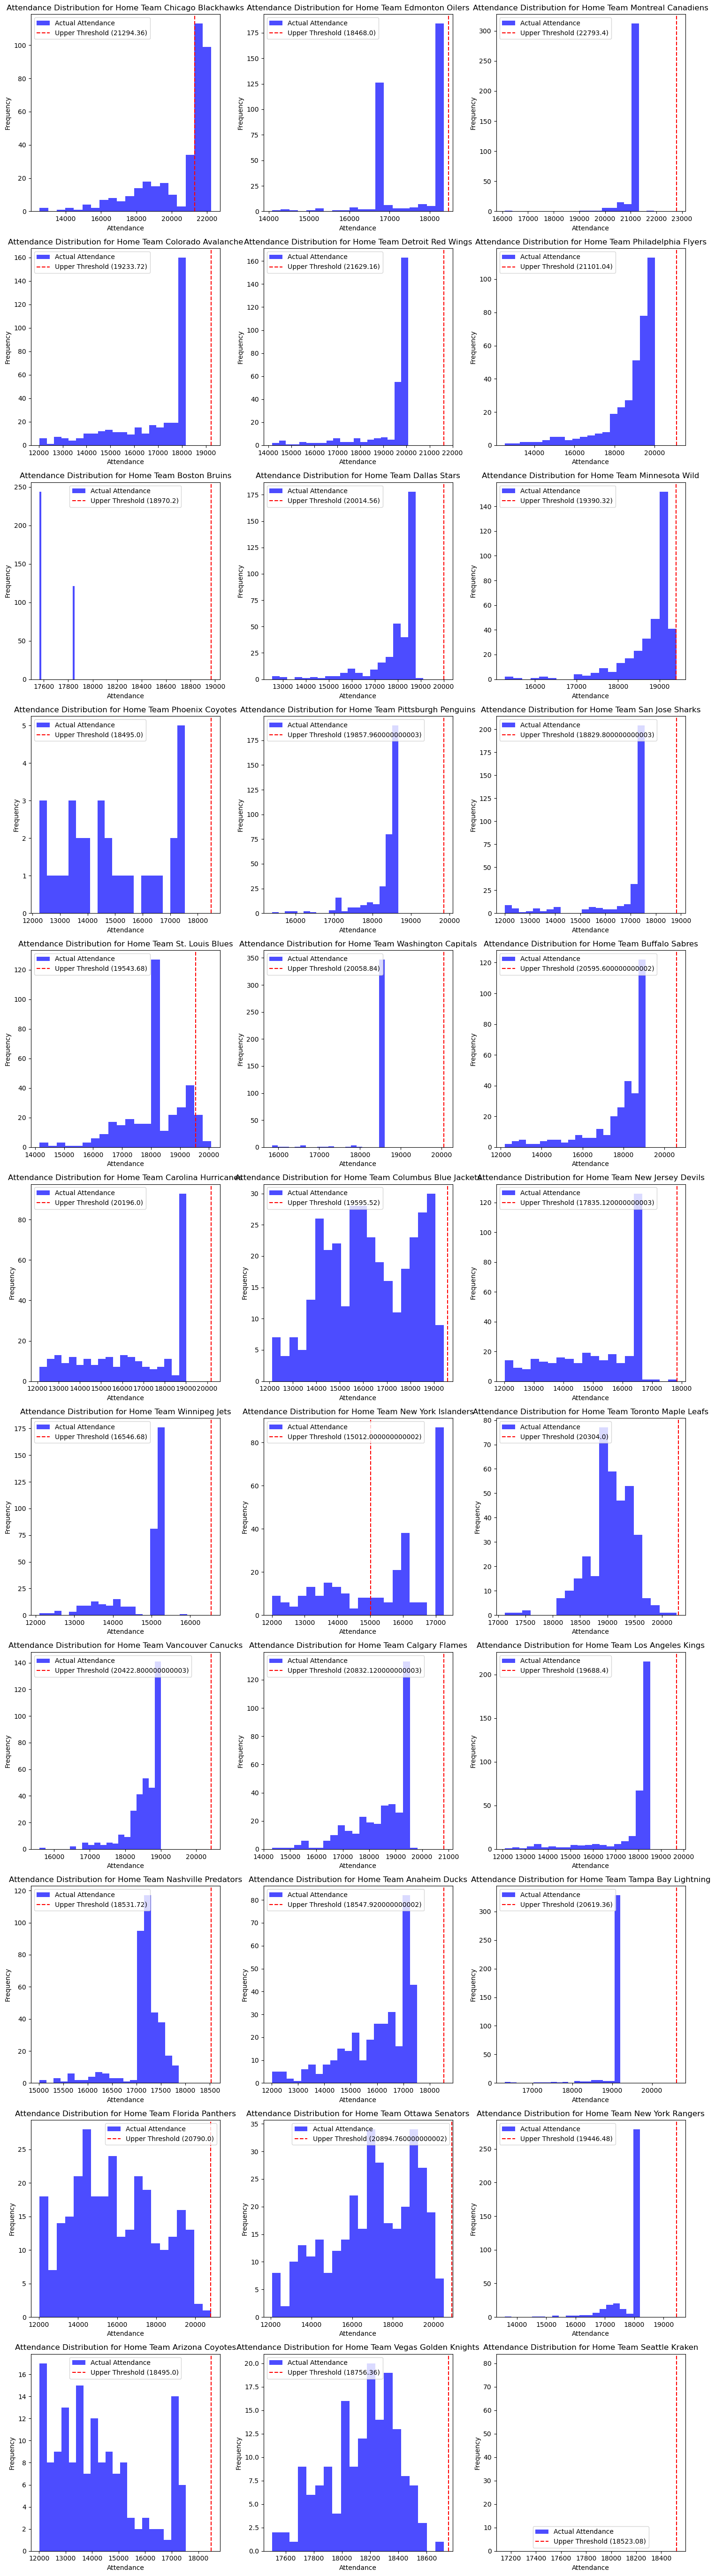

In [29]:
##### KEEP FOR NOW
##### POTENTIALLY MOVE TO VISUALIZATION

#### ALREADY PARTIALLY THERE


# Calculate number of rows and columns for the histogram grid
n = len(home_teams)  # Number of teams
m = 3  # Number of columns in the grid (you can change this)

# Calculate the required number of rows to fit all histograms
rows = (n + m - 1) // m  # This rounds up to ensure all histograms fit

# Create a grid of histograms for each home team
fig, axes = plt.subplots(nrows=rows, ncols=m, figsize=(15, rows * 5))

# Flatten the axes array to make indexing easier
axes = axes.flatten()

# Loop through each home team
for i, home_team in enumerate(home_teams):
    # Filter data for the current home team
    team_data = df_att[df_att['H'] == home_team]

    upper_threshold = team_data['CAP'].iloc[0] * 1.08

    # Plot histogram for attendance
    axes[i].hist(team_data['A'], bins=20, alpha=0.7, label='Actual Attendance', color='blue')
    axes[i].axvline(upper_threshold, color='red', linestyle='--', label=f'Upper Threshold ({upper_threshold})')
    axes[i].set_title(f'Attendance Distribution for Home Team {home_team}')
    axes[i].set_xlabel('Attendance')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Hide unused subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Chicago Blackhawks and Dependent Variable A: 1052543676.348516



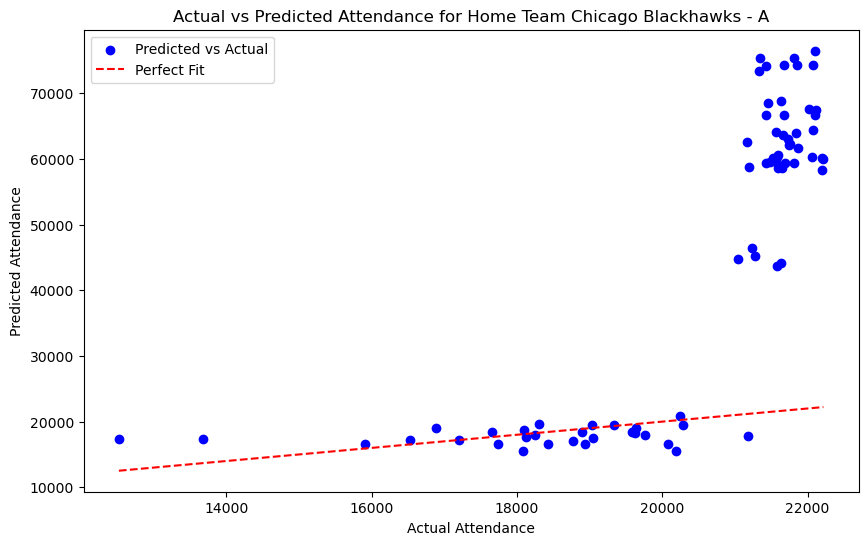

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Edmonton Oilers and Dependent Variable A: 18285721.494929776



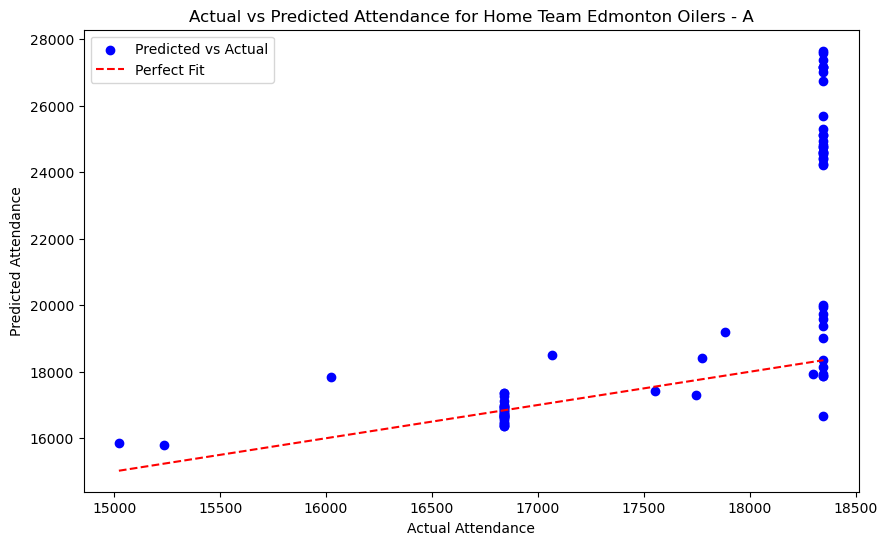


Mean Squared Error (MSE) for Home Team Montreal Canadiens and Dependent Variable A: 59266.74827512016



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


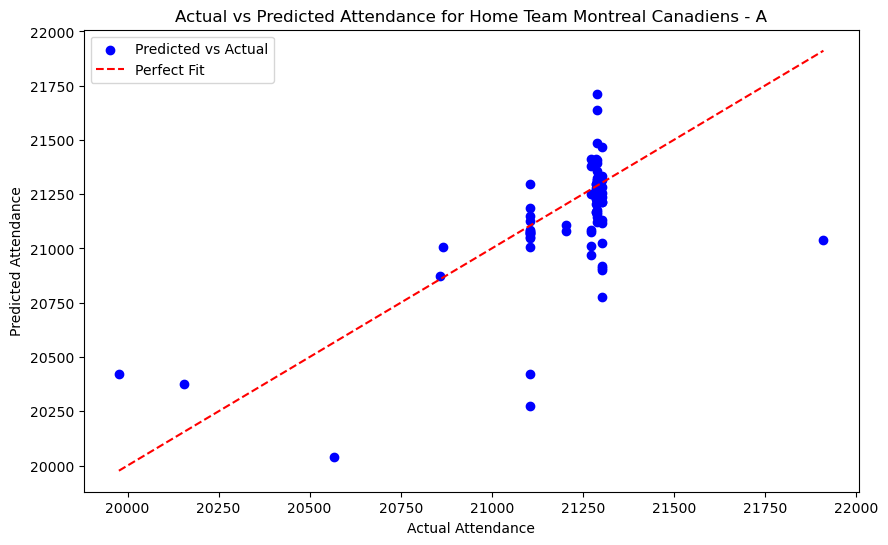

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Colorado Avalanche and Dependent Variable A: 1479292.6076181107



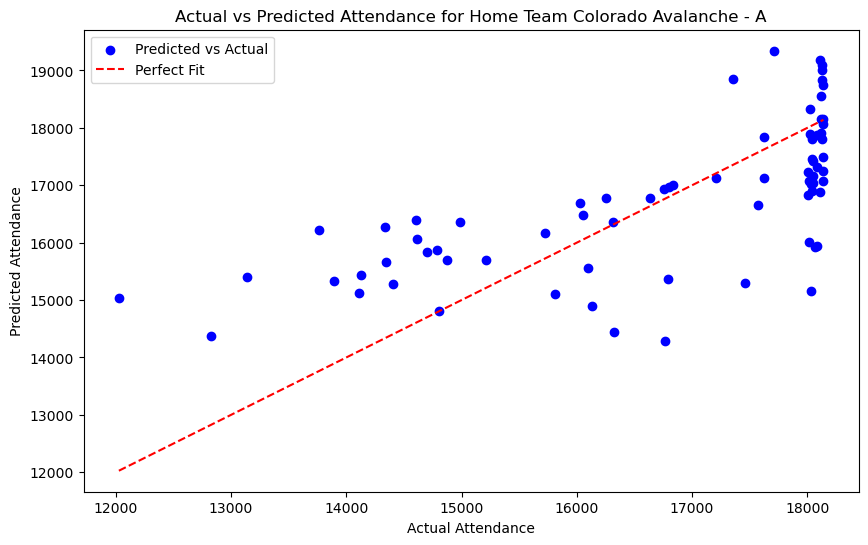

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Detroit Red Wings and Dependent Variable A: 646013.0896318103



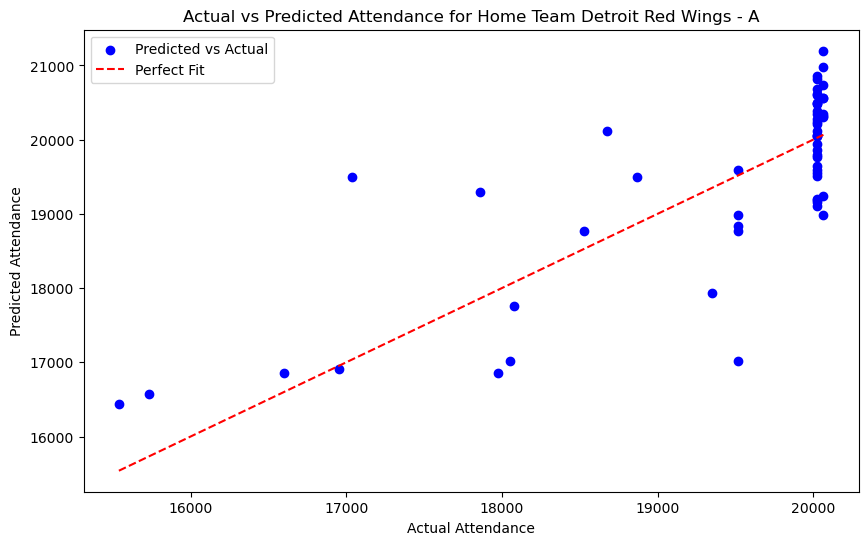

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Philadelphia Flyers and Dependent Variable A: 1275742.9035188404



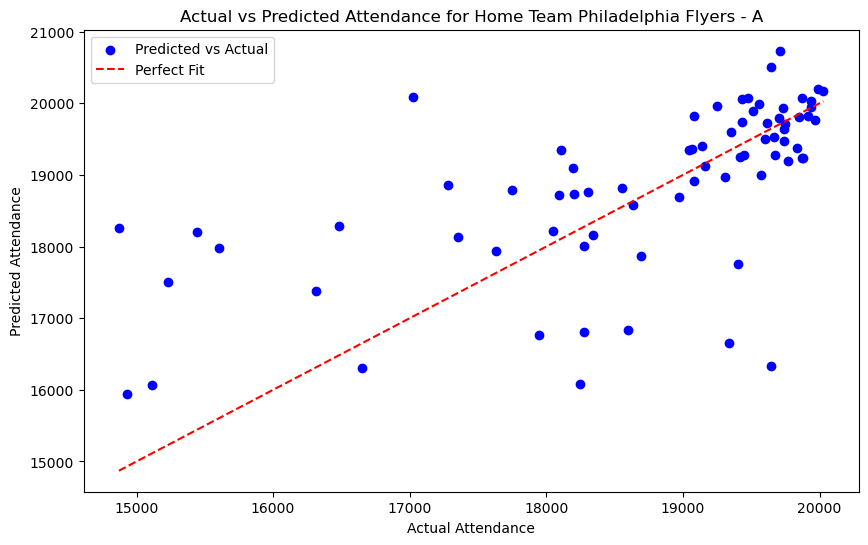

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Boston Bruins and Dependent Variable A: 1142.1700349869184



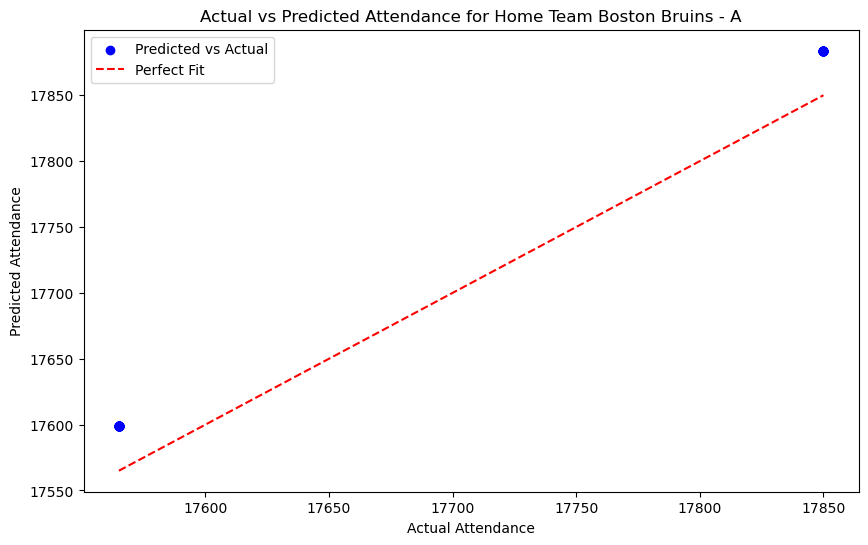

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Dallas Stars and Dependent Variable A: 572051.3689658687



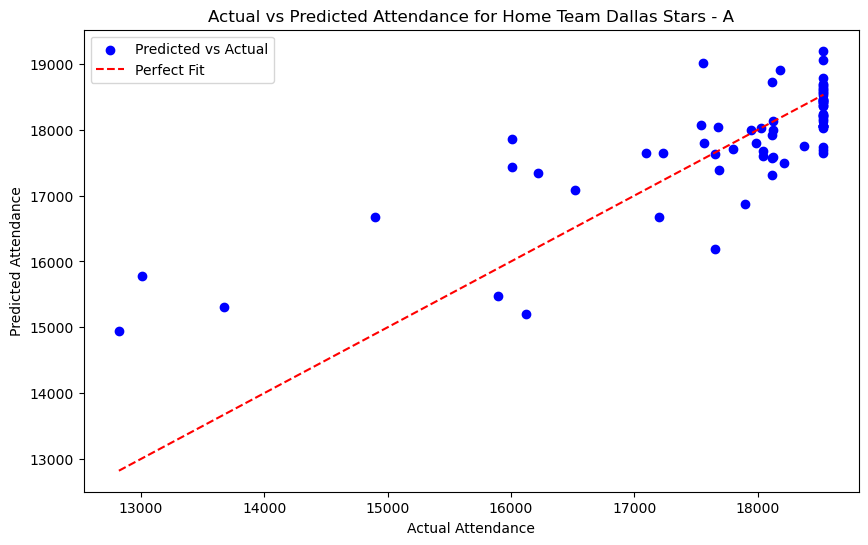

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Minnesota Wild and Dependent Variable A: 734363570.7464668



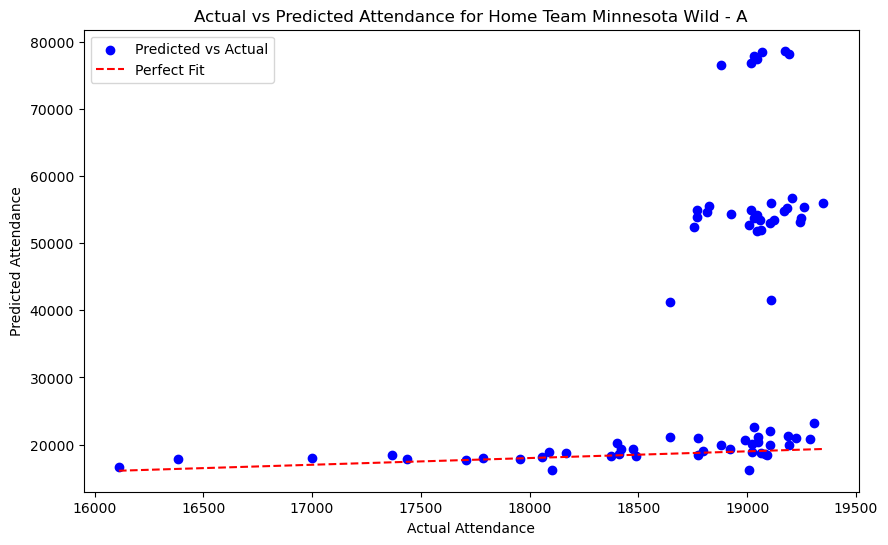


Mean Squared Error (MSE) for Home Team Phoenix Coyotes and Dependent Variable A: 77587821.89260706



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


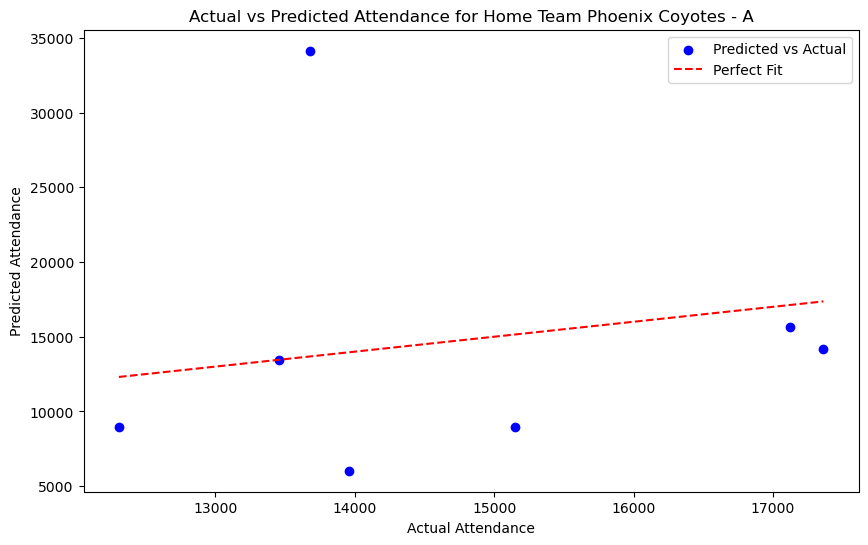

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Pittsburgh Penguins and Dependent Variable A: 113980.29911538993



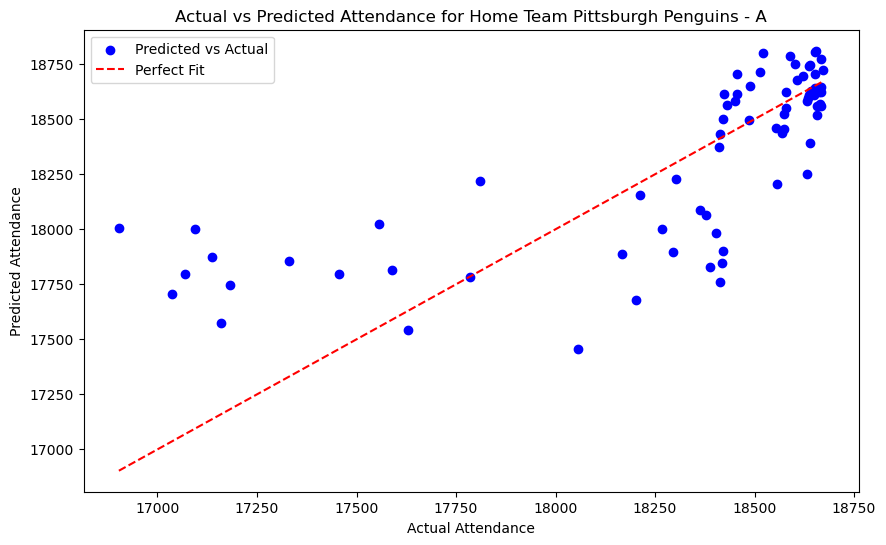

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team San Jose Sharks and Dependent Variable A: 1182813.5511382578



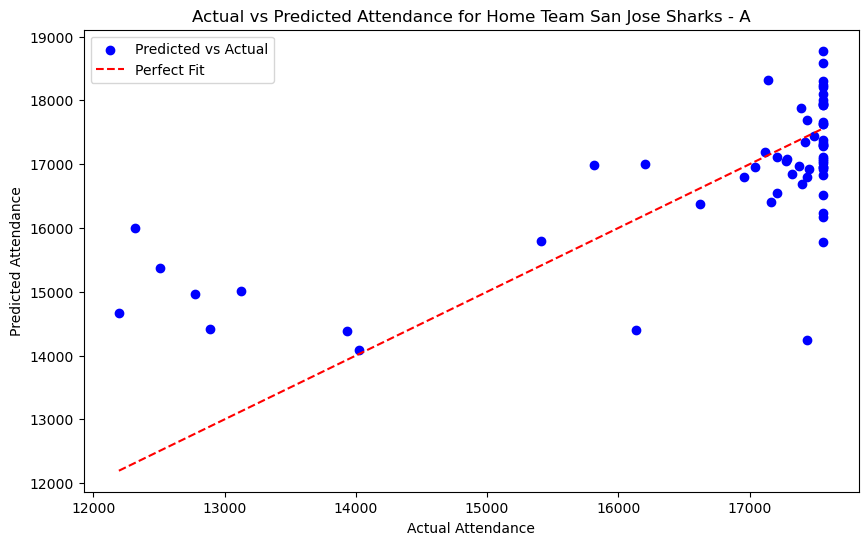

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team St. Louis Blues and Dependent Variable A: 1395362.5645184608



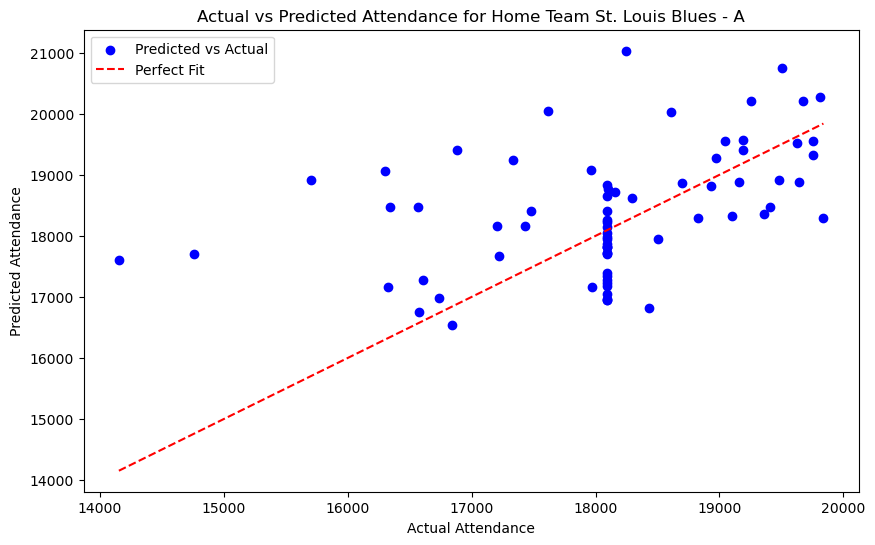


Mean Squared Error (MSE) for Home Team Washington Capitals and Dependent Variable A: 95376.92588727278



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


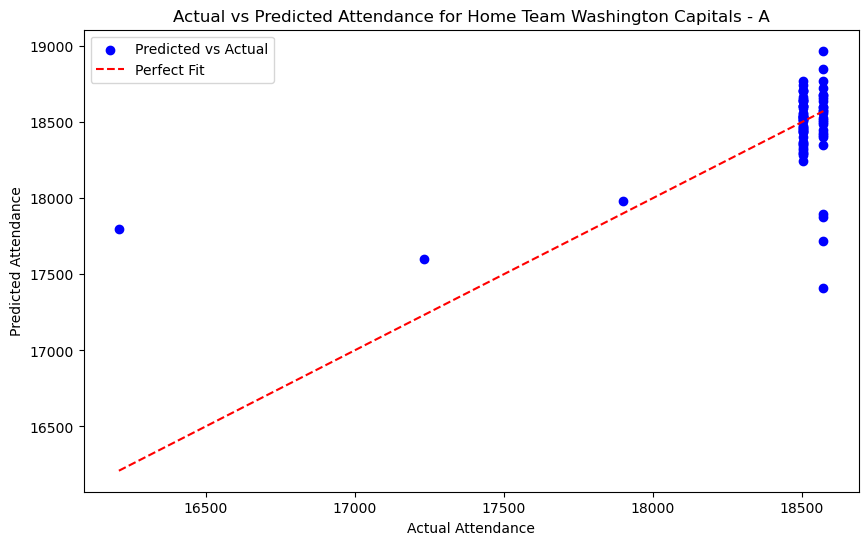

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Buffalo Sabres and Dependent Variable A: 1840841.3268625461



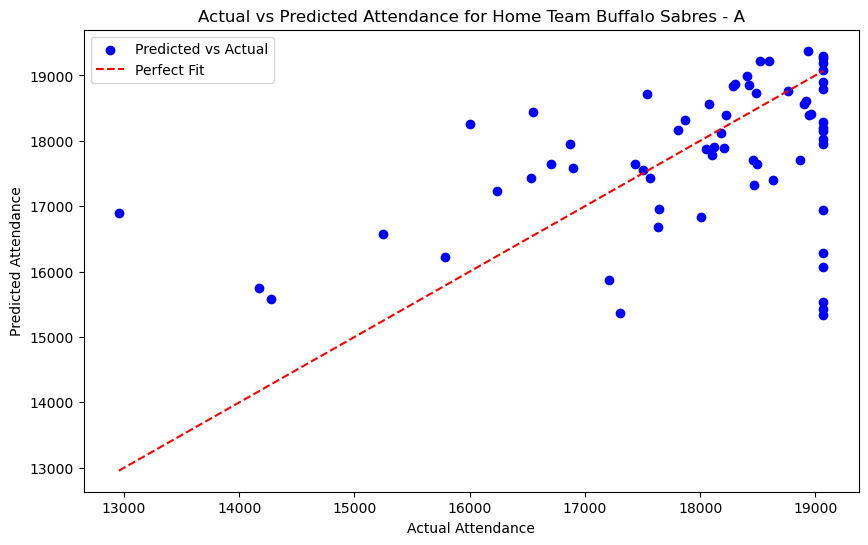

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Carolina Hurricanes and Dependent Variable A: 1883312.5275525718



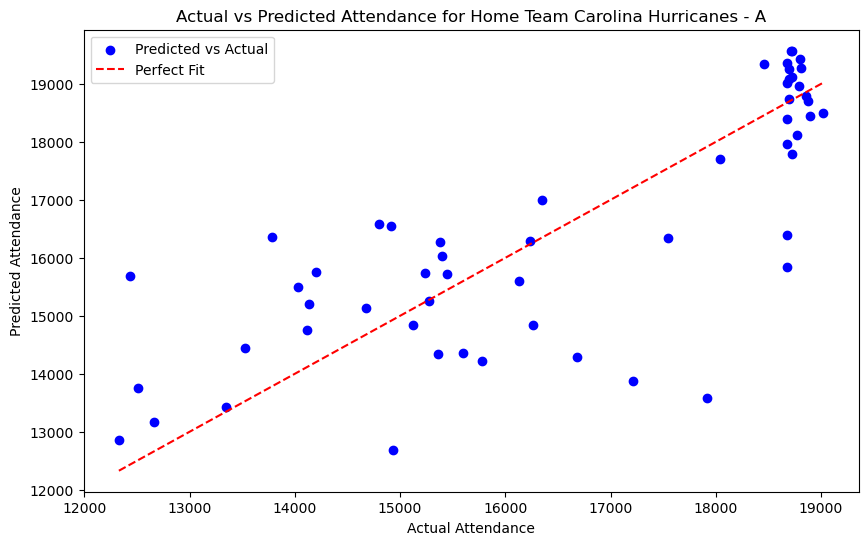

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Columbus Blue Jackets and Dependent Variable A: 2722174.3427886637



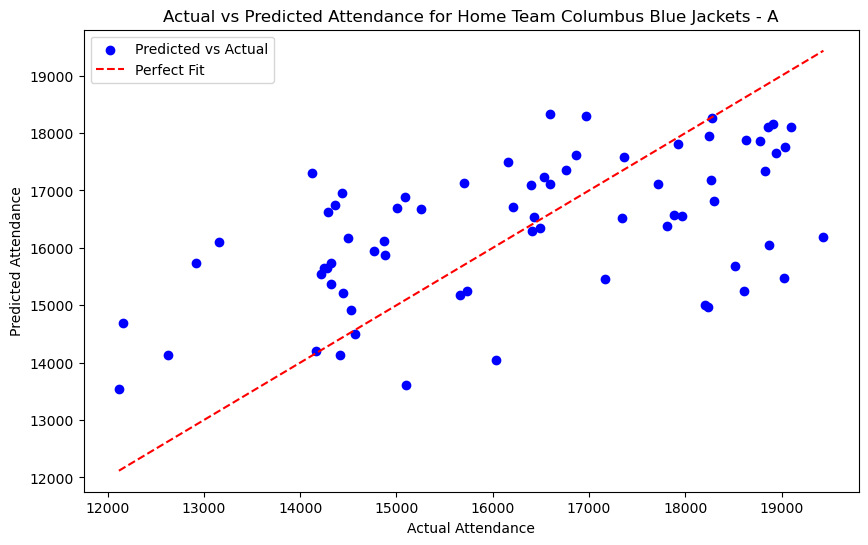

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team New Jersey Devils and Dependent Variable A: 1608994.2797457743



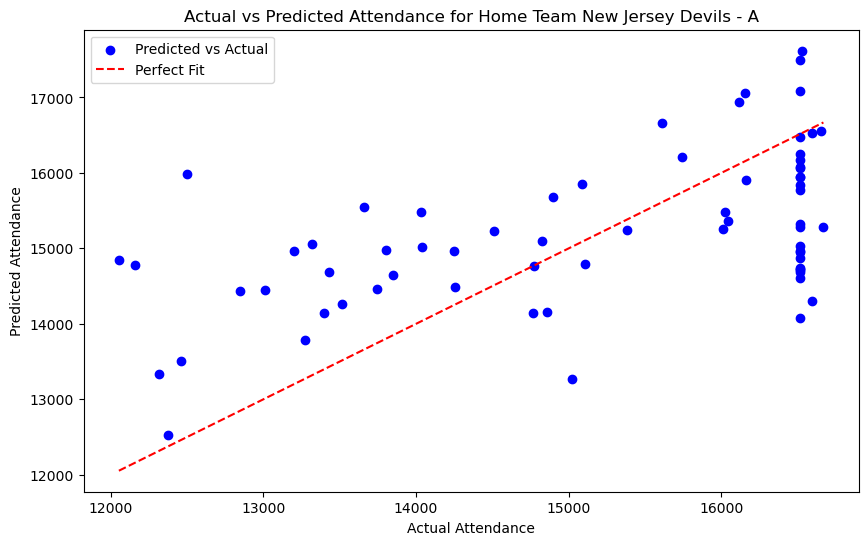

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Winnipeg Jets and Dependent Variable A: 187592.80526074299



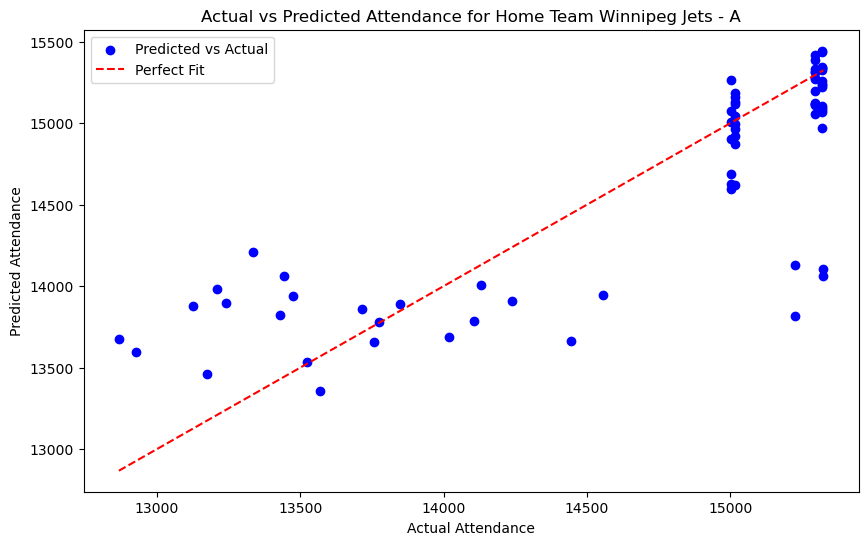

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team New York Islanders and Dependent Variable A: 152112082.60043502



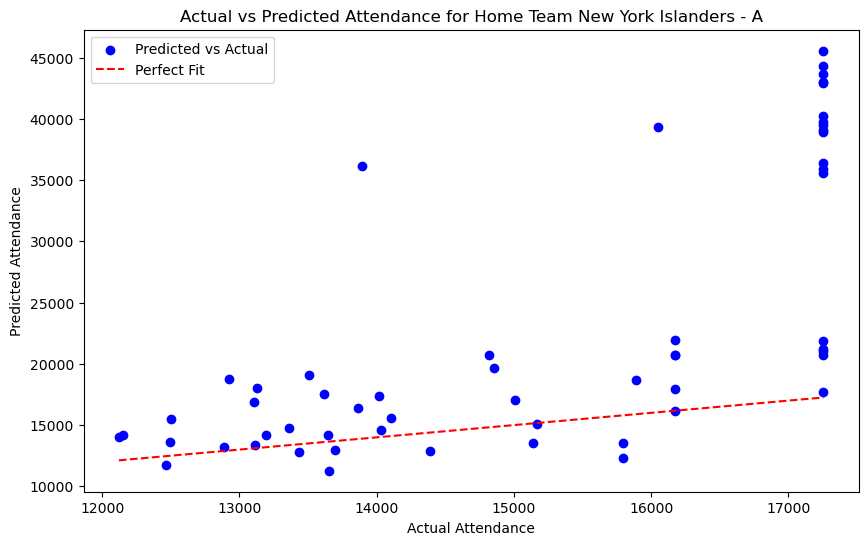

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Toronto Maple Leafs and Dependent Variable A: 160085.01888035526



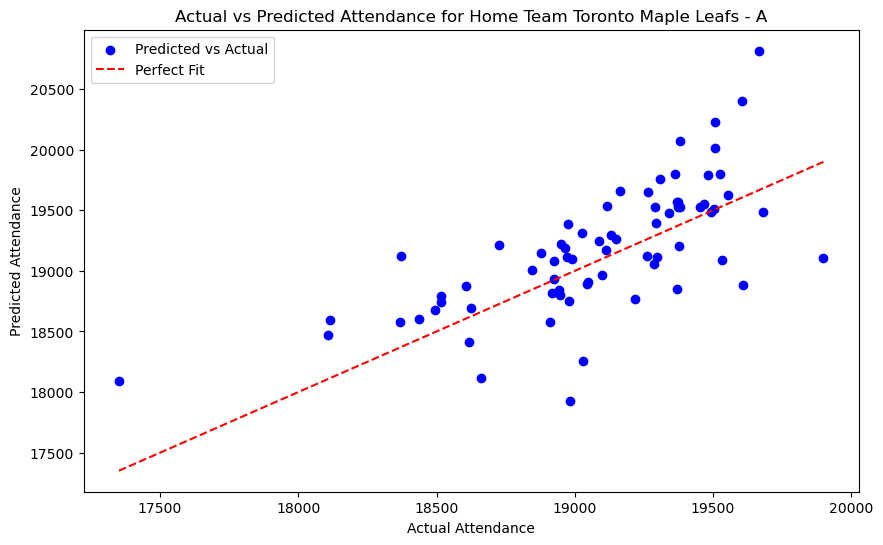


Mean Squared Error (MSE) for Home Team Vancouver Canucks and Dependent Variable A: 148623.95888422997



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


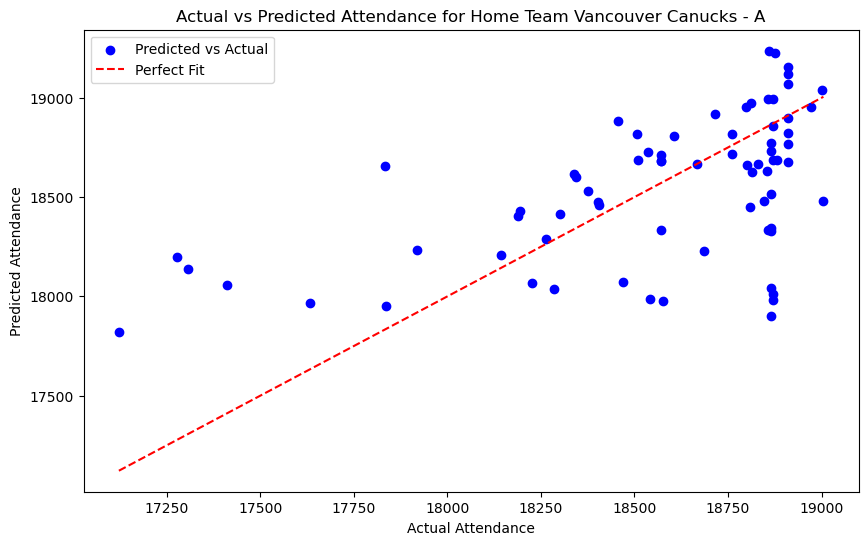

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Calgary Flames and Dependent Variable A: 312140.91005475365



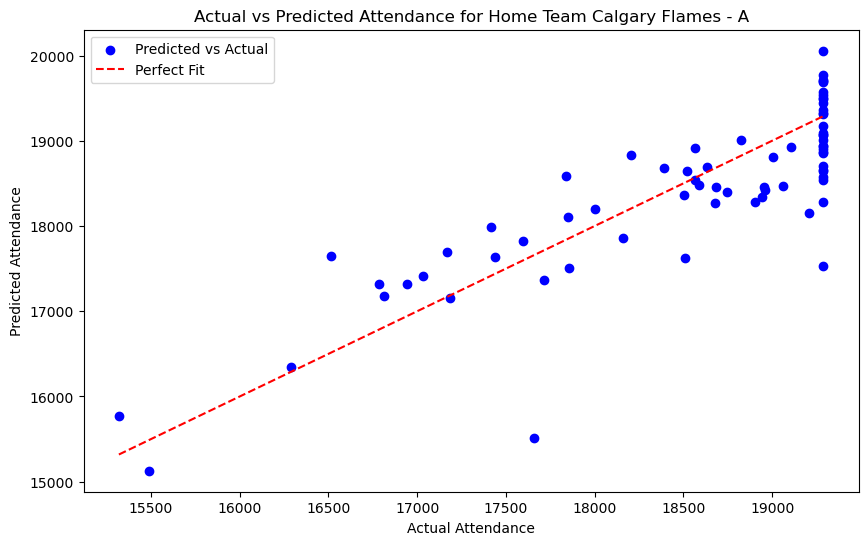


Mean Squared Error (MSE) for Home Team Los Angeles Kings and Dependent Variable A: 821532.969518479



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


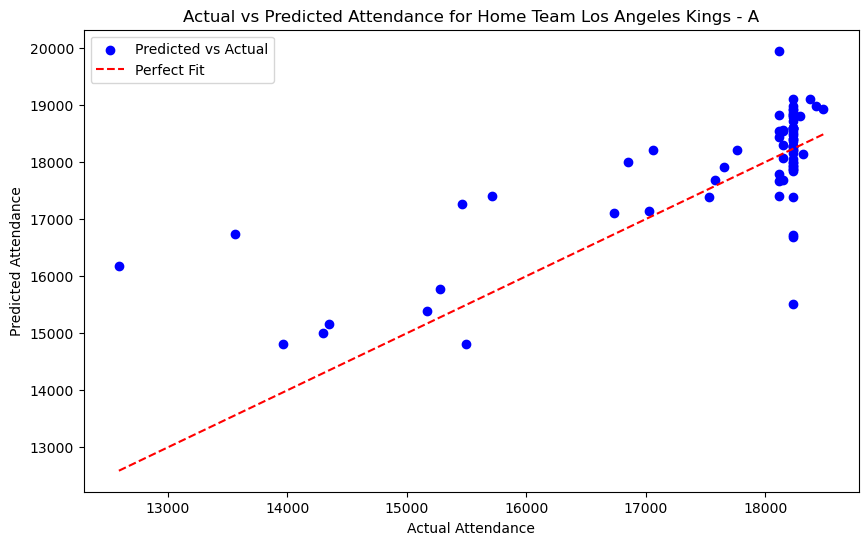

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Nashville Predators and Dependent Variable A: 148659.09638496742



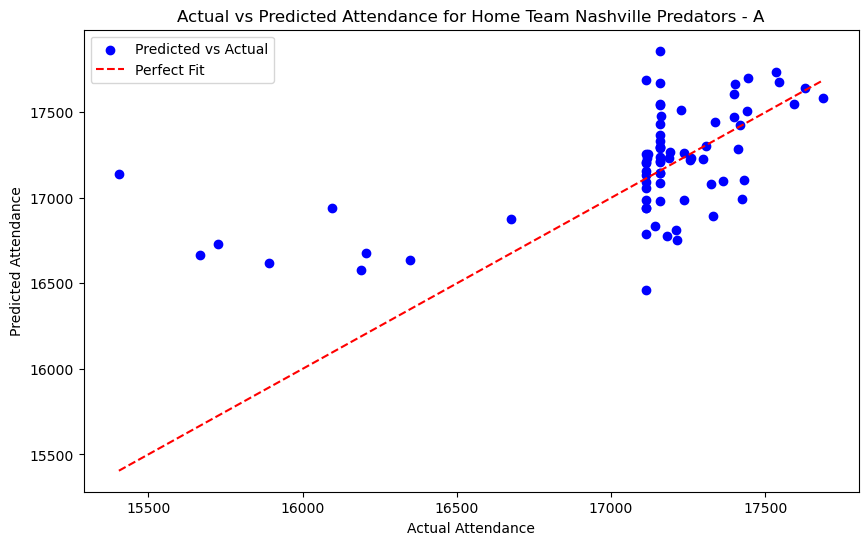


Mean Squared Error (MSE) for Home Team Anaheim Ducks and Dependent Variable A: 1516743.3636446565



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


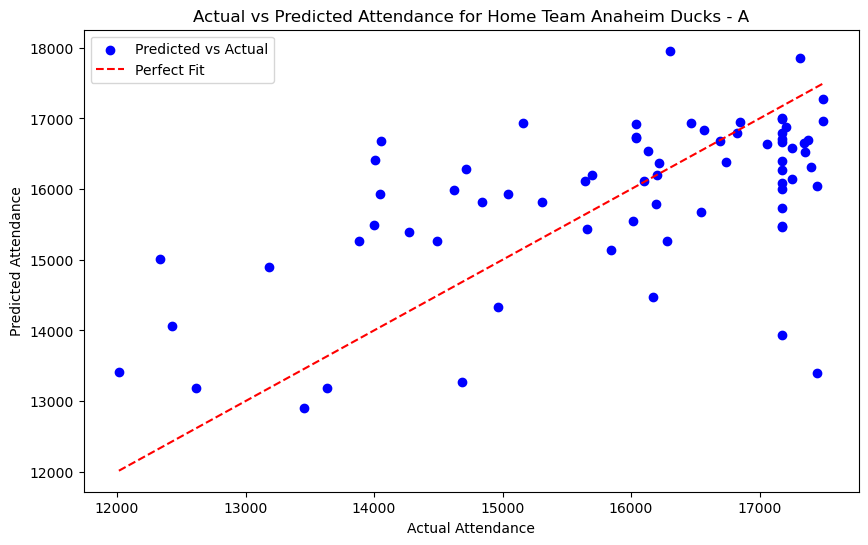

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Tampa Bay Lightning and Dependent Variable A: 122126.22929642991



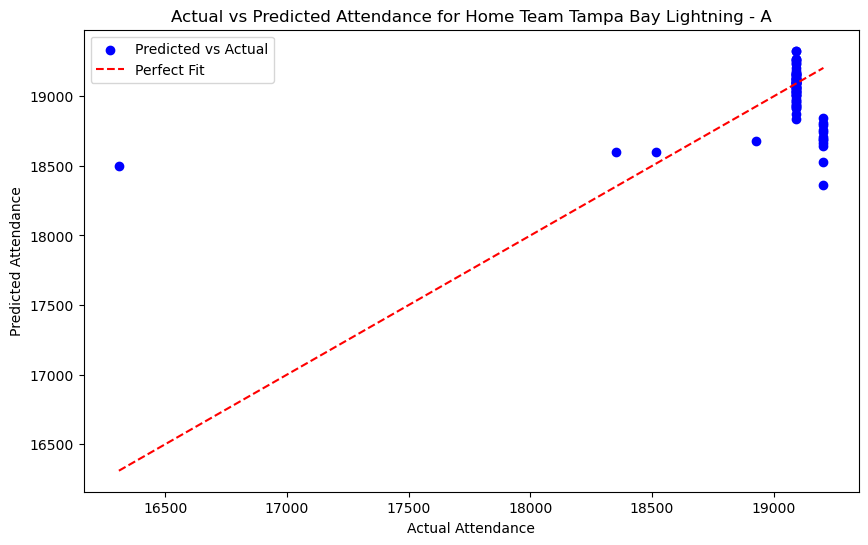

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Florida Panthers and Dependent Variable A: 4181991.0300738276



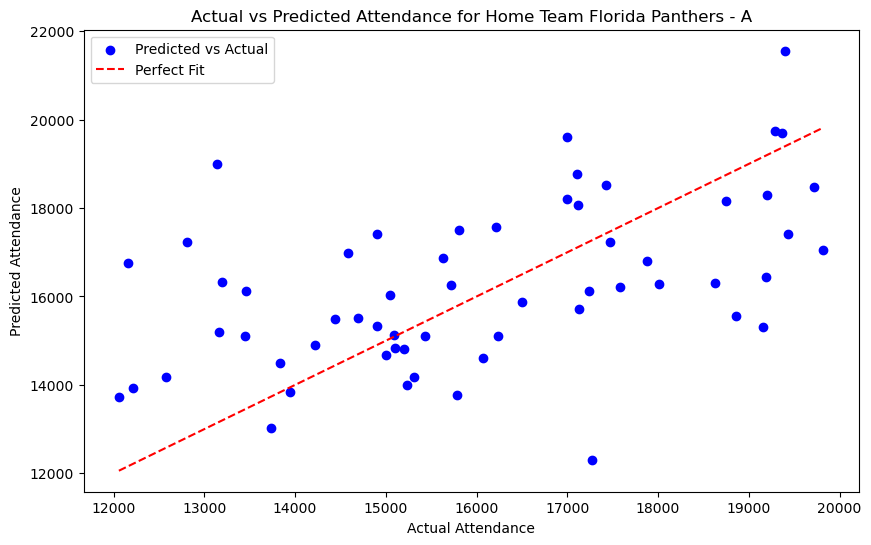

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Ottawa Senators and Dependent Variable A: 2906699.5449384153



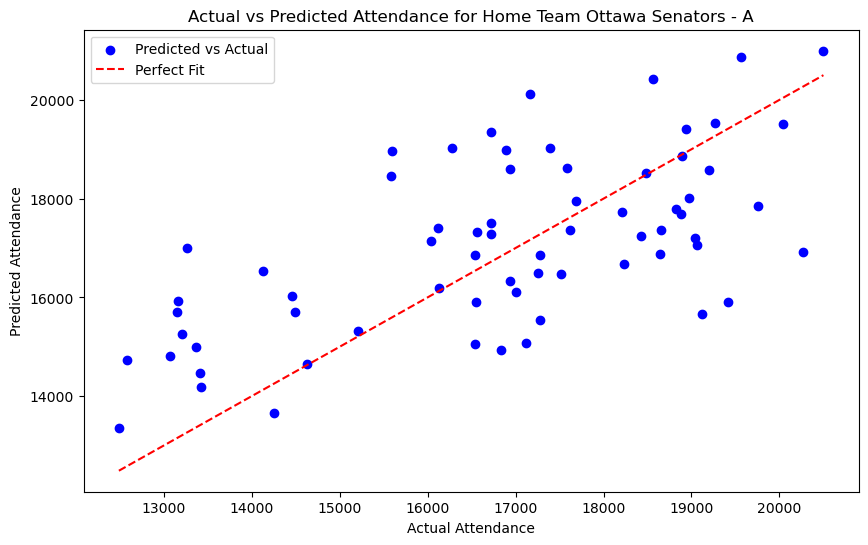


Mean Squared Error (MSE) for Home Team New York Rangers and Dependent Variable A: 111187.31680580745



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


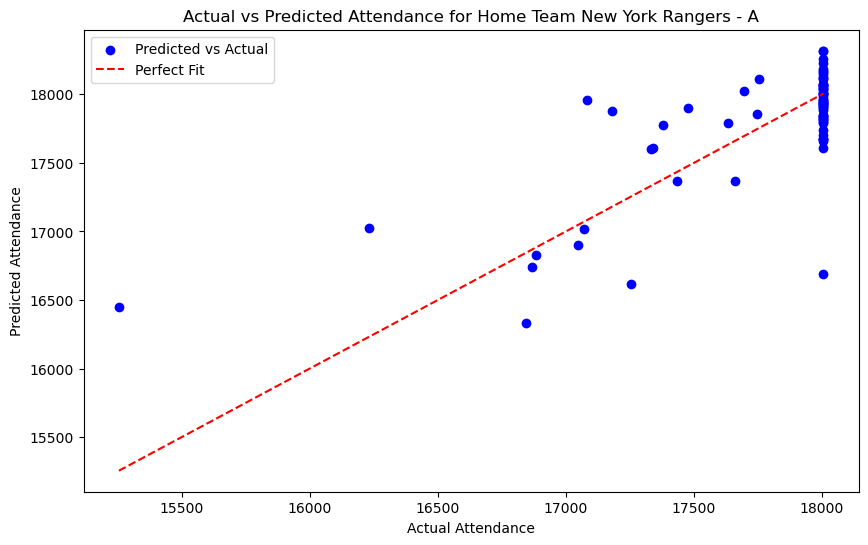

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Arizona Coyotes and Dependent Variable A: 2901108.627247172



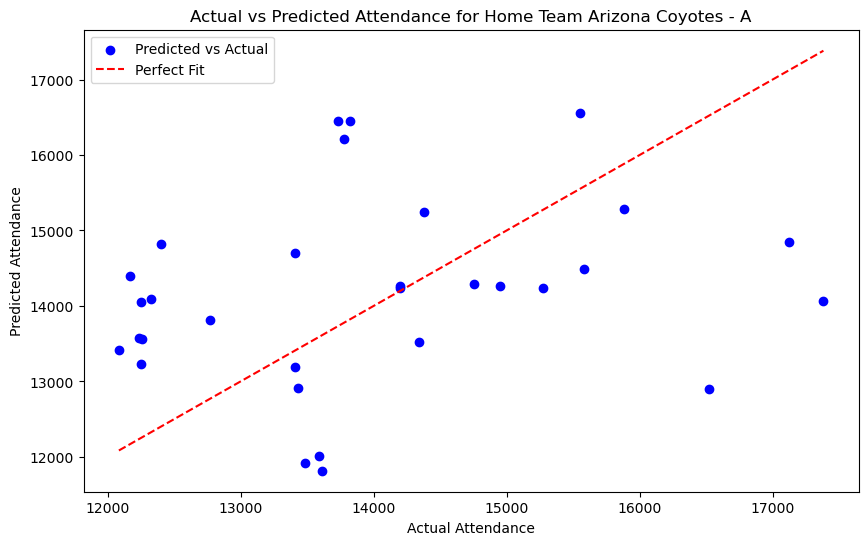

/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values



Mean Squared Error (MSE) for Home Team Vegas Golden Knights and Dependent Variable A: 337098333467.01385



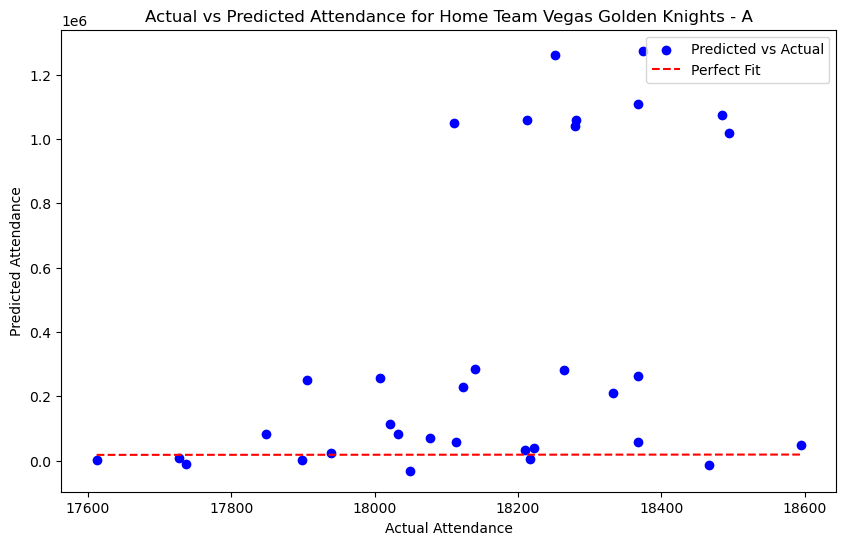


Mean Squared Error (MSE) for Home Team Seattle Kraken and Dependent Variable A: 1.7456679546672813



/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:16: UserWarning: No censored observations; use regression methods for uncensored data
  warnings.warn("No censored observations; use regression methods for uncensored data")
/Users/anneducroo/Library/CloudStorage/Dropbox/Mac (2)/Documents/PRINCETON/SPRING 2025/ORF499/tobit.py:24: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  x_split = x[split].values


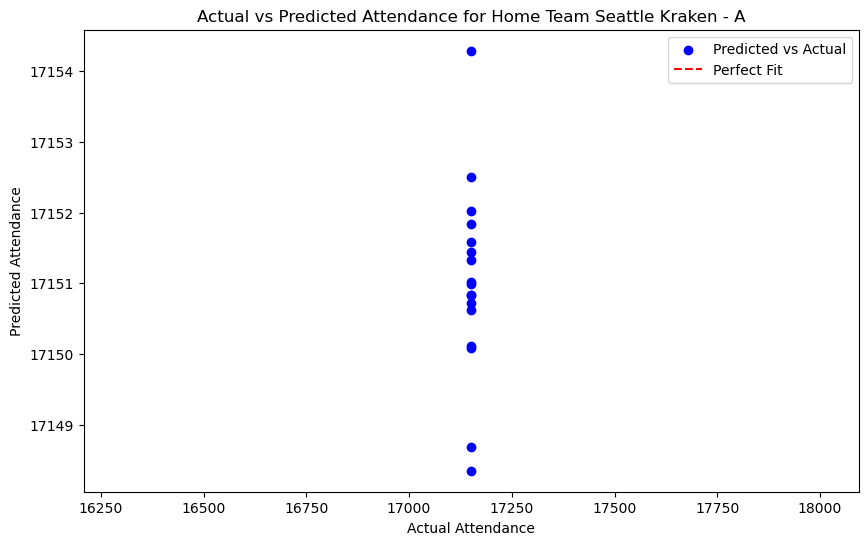

In [23]:
##### KEEP FOR NOW


# Assuming 'HomeTeam' column contains the home team names, and 'df_att' is the attendance dataframe

home_teams = df_att['H'].unique()  # Get the list of unique home teams
dependent_vars = ['A']

rand_seed = 34

# Loop through each home team
for home_team in home_teams:
    # Filter data for the current home team
    team_data = df_att[df_att['H'] == home_team]

    upper_threshold = team_data['CAP'].iloc[0] * 1.025
    
    for dep in dependent_vars:
        X = team_data.drop(columns=['A', 'LA', 'PA', 'LPA', 'LA/LC', 'H', 'V'])
        y = team_data[dep]

        # Split the data into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

        # Create the censored variable based on attendance
        cens = pd.Series(np.zeros(len(team_data)), index=team_data.index)
        
        # Apply censoring based on attendance
        cens[team_data['A'] >= upper_threshold] = 1  # Right-censored

        # Fit the Tobit model on the training data
        model = TobitModel()
        model.fit(X_train, y_train, cens, verbose=False)

        # Predict on the test set
        y_pred = model.predict(X_test)

        # Calculate MSE for the test set
        mse_test = mean_squared_error(y_test, y_pred)
        print(f'\nMean Squared Error (MSE) for Home Team {home_team} and Dependent Variable {dep}: {mse_test}\n')

        # Plot the Actual vs Predicted for this home team
        plt.figure(figsize=(10, 6))
        plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
        plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
        plt.xlabel('Actual Attendance')
        plt.ylabel('Predicted Attendance')
        plt.title(f'Actual vs Predicted Attendance for Home Team {home_team} - {dep}')
        plt.legend()
        plt.show()

In [63]:
def OLS_vs_Tobit(df_team, upper_threshold):
    # Define dependent variable
    #dependent_vars = ['A', 'LA', 'PA', 'LPA', 'LA/LC']\

    dependent_vars = ['LA']
    
    rand_seed = 34
        
    for dep in dependent_vars:
        X = df_team.drop(columns=['A', 'LA', 'PA', 'LPA', 'LA/LC', 'H', 'V'])
        y = df_team[dep]

        # Split the data into train and test sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

        # Create the censored variable based on attendance
        cens = pd.Series(np.zeros(len(df_team)), index=df_team.index)
        
        # Apply censoring based on attendance
        cens[df_team['A'] >= upper_threshold] = 1  # Right-censored

        # Fit the Tobit model on the training data
        tobit_model = TobitModel()
        tobit_model.fit(X_train, y_train, cens, verbose=False)

        # Predict on the test set using Tobit
        y_pred_tobit = tobit_model.predict(X_test)

        # Fit OLS model
        ols_model = LinearRegression()
        ols_model.fit(X_train, y_train)

        # Predict on the test set using OLS
        y_pred_ols = ols_model.predict(X_test)

        # Calculate MSE for both models
        mse_tobit = mean_squared_error(y_test, y_pred_tobit)
        mse_ols = mean_squared_error(y_test, y_pred_ols)

        # Print results only if Tobit has a lower MSE
        if mse_tobit < mse_ols:
            print(f'dependent variable {dep}')
            print(f'\nMean Squared Error (MSE) for Home Team {df_team["H"].iloc[0]}:')
            print(f'  - Tobit: {mse_tobit}')
            print(f'  - OLS: {mse_ols}\n')

            # Plot the Actual vs Predicted for both models
            plt.figure(figsize=(10, 6))
            plt.scatter(y_test, y_pred_tobit, color='blue', alpha=0.6, label='Tobit Predictions')
            plt.scatter(y_test, y_pred_ols, color='green', alpha=0.6, label='OLS Predictions')
            plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')
            plt.xlabel('Actual Attendance')
            plt.ylabel('Predicted Attendance')
            plt.title(f'Actual vs Predicted Attendance for Home Team {df_team["H"].iloc[0]}')
            plt.legend()
            plt.show()

            return 1
    return 0


dependent variable LA

Mean Squared Error (MSE) for Home Team Chicago Blackhawks:
  - Tobit: 0.00545916181572628
  - OLS: 0.005477276840606369



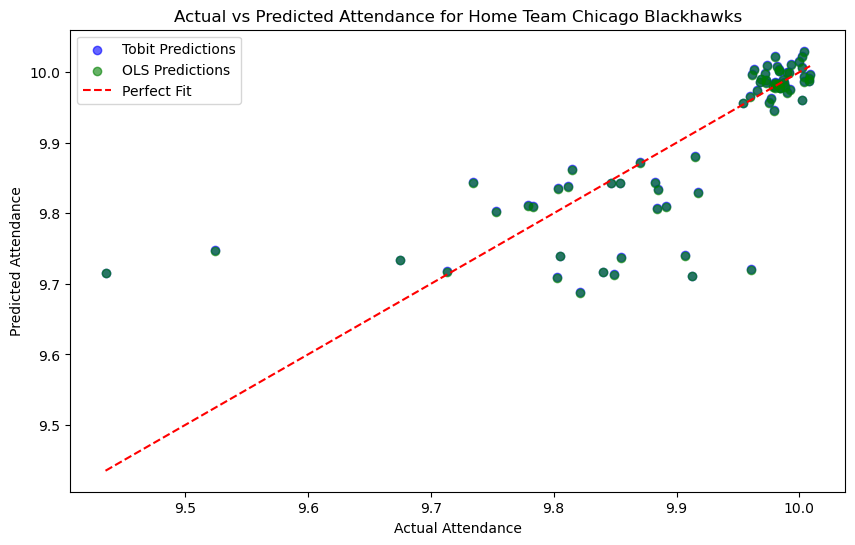


Running OLS_vs_Tobit for Chicago Blackhawks with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Chicago Blackhawks:
  - Tobit: 0.00545916181572628
  - OLS: 0.005477276840606369



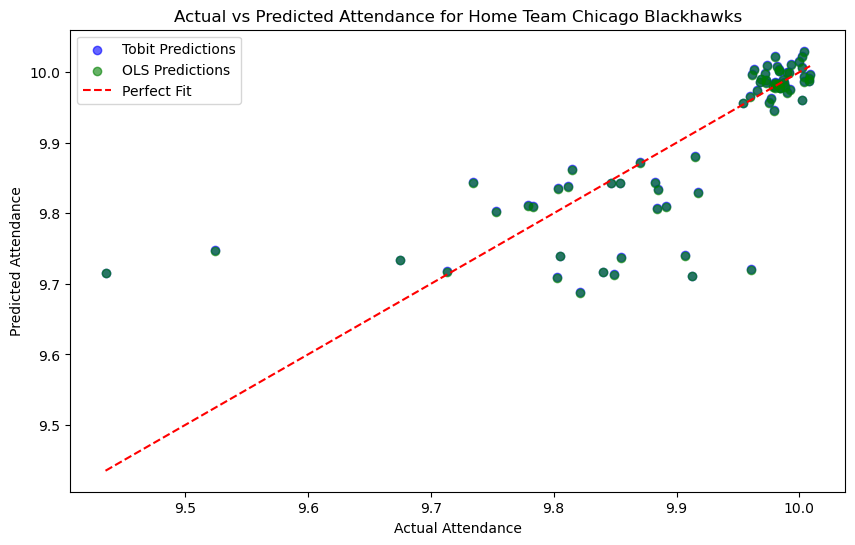


Running OLS_vs_Tobit for Chicago Blackhawks with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Chicago Blackhawks:
  - Tobit: 0.00545916181572628
  - OLS: 0.005477276840606369



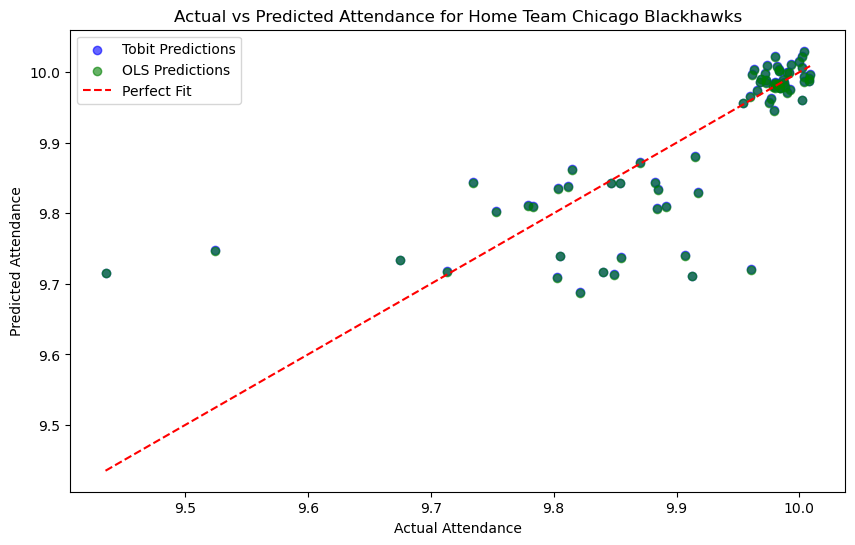


Running OLS_vs_Tobit for Chicago Blackhawks with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



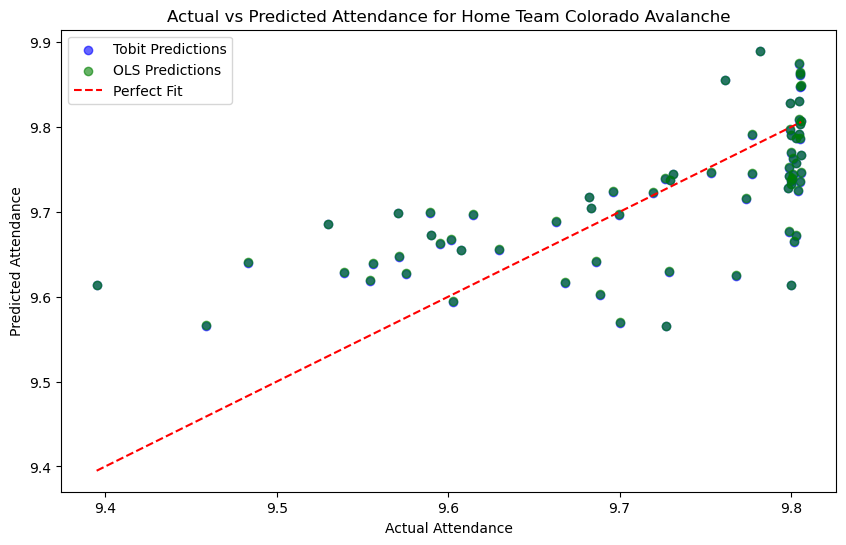


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



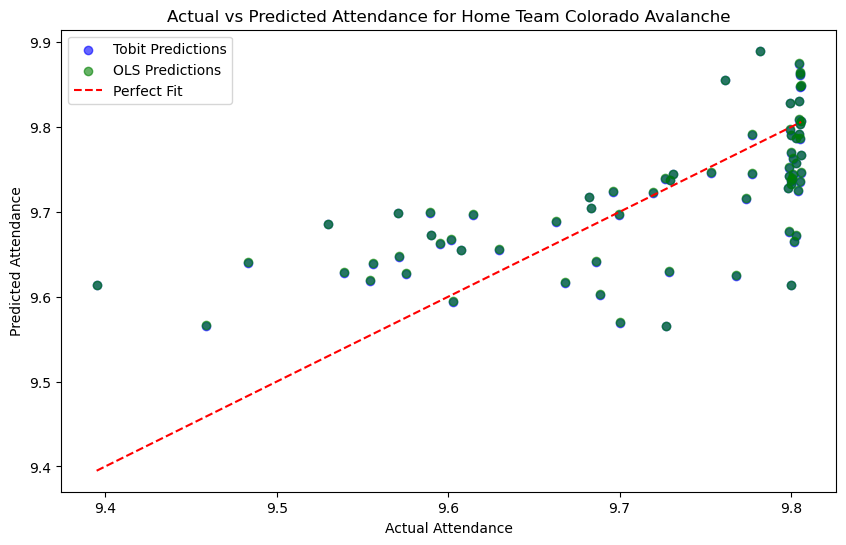


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



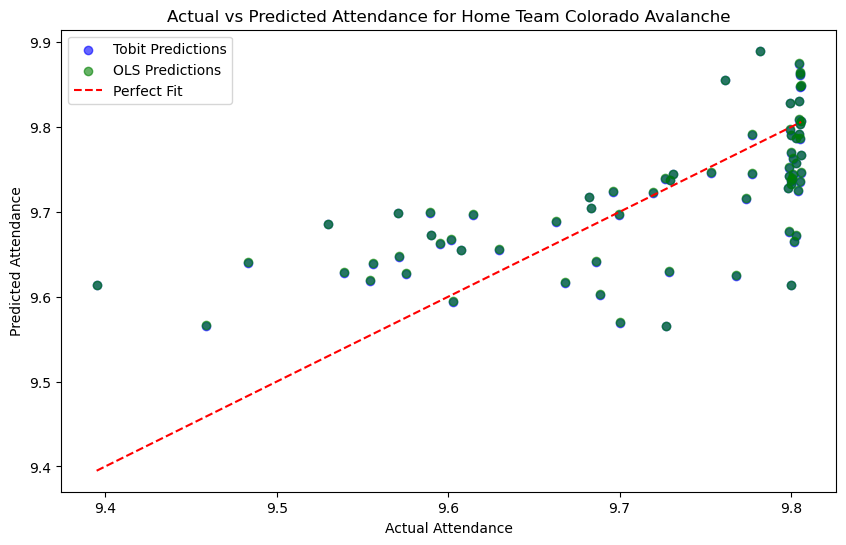


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



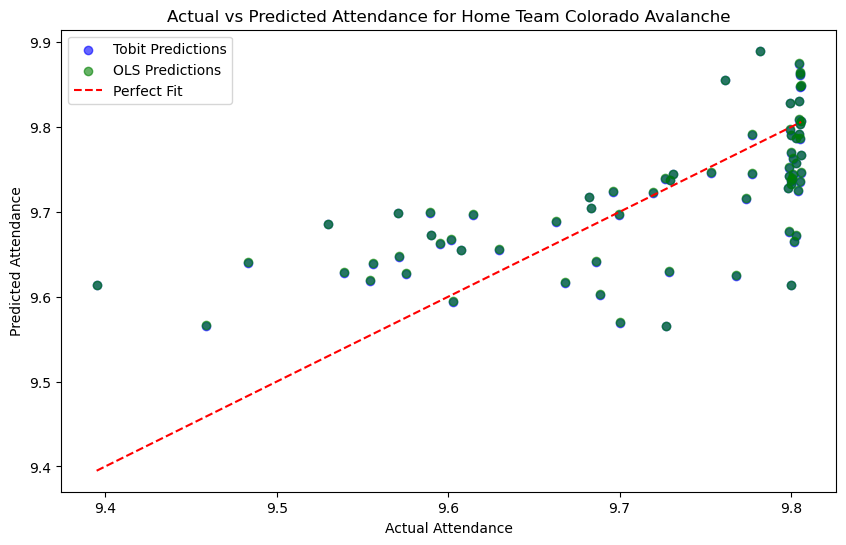


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



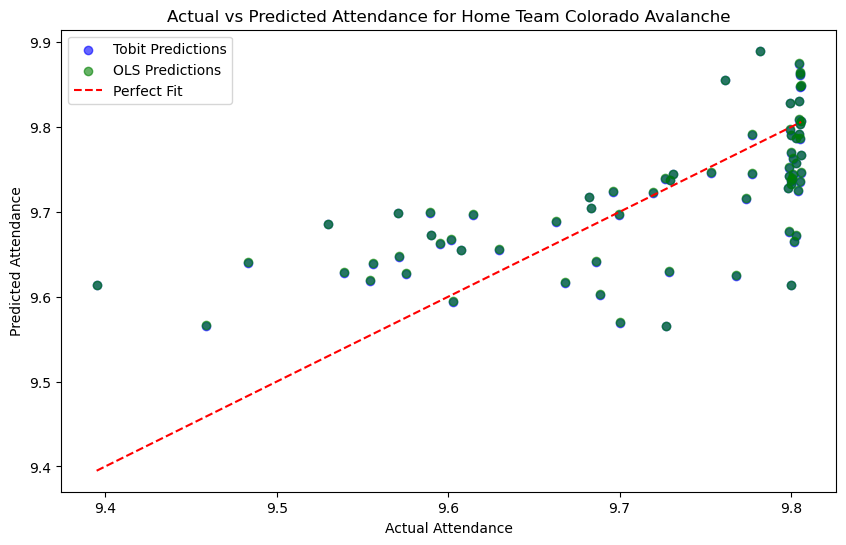


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Colorado Avalanche:
  - Tobit: 0.006202193033815626
  - OLS: 0.0062035761537536085



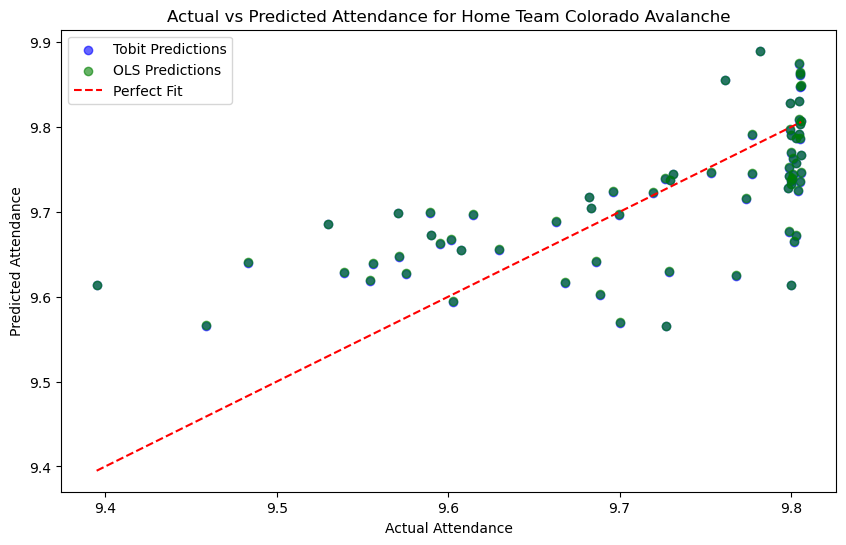


Running OLS_vs_Tobit for Colorado Avalanche with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



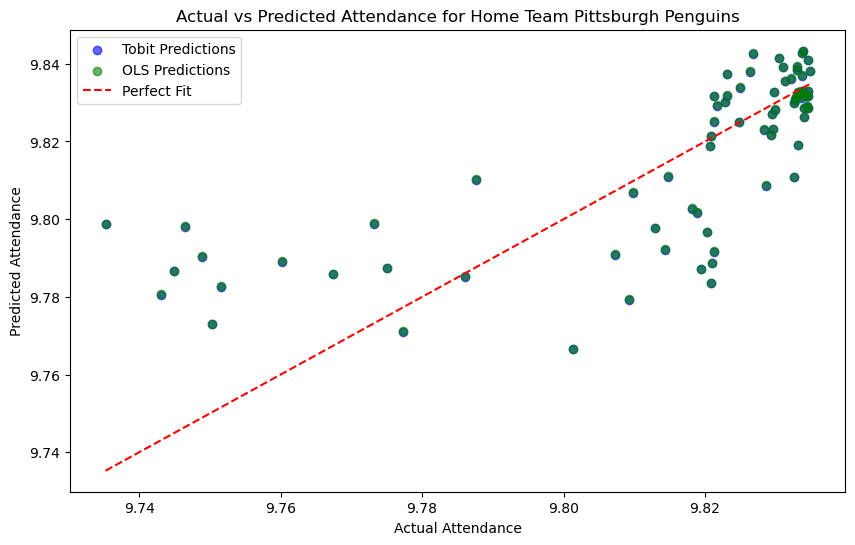


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



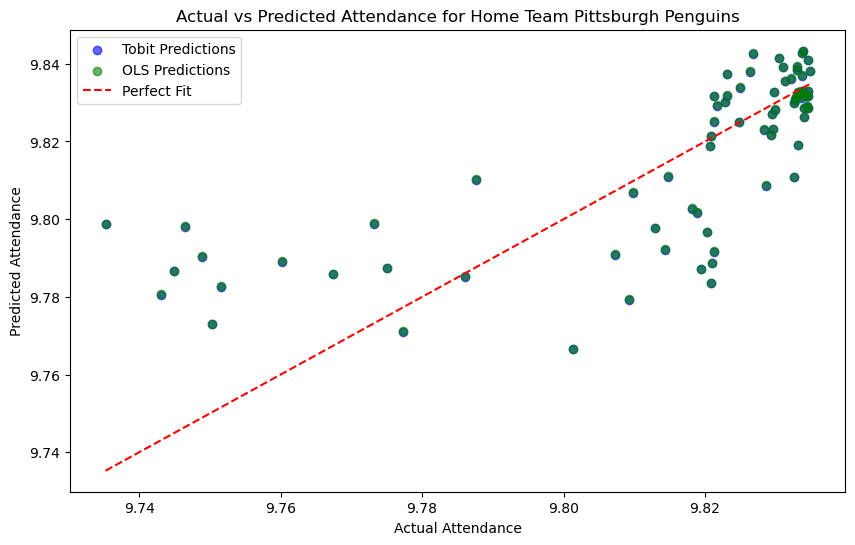


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



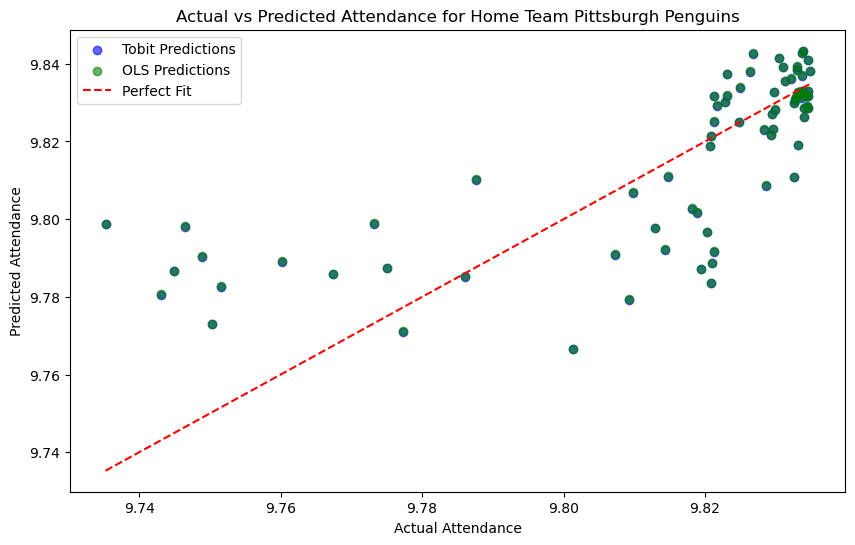


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



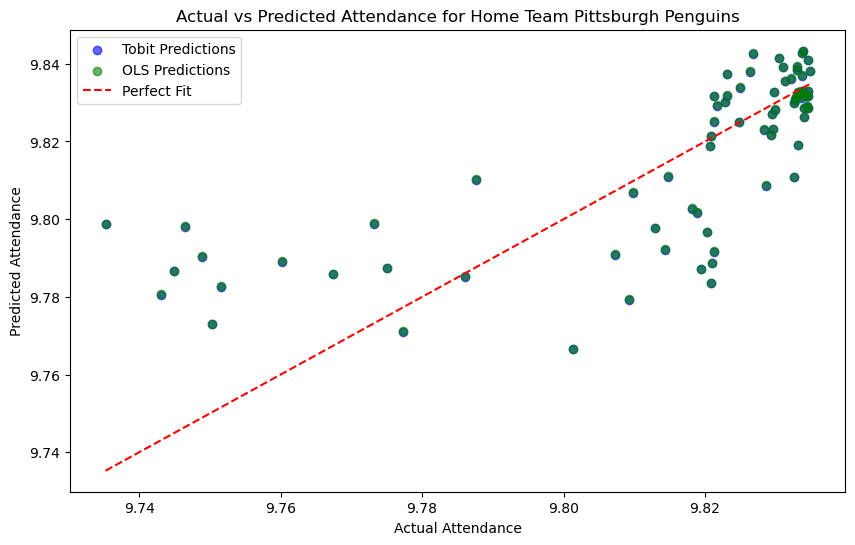


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



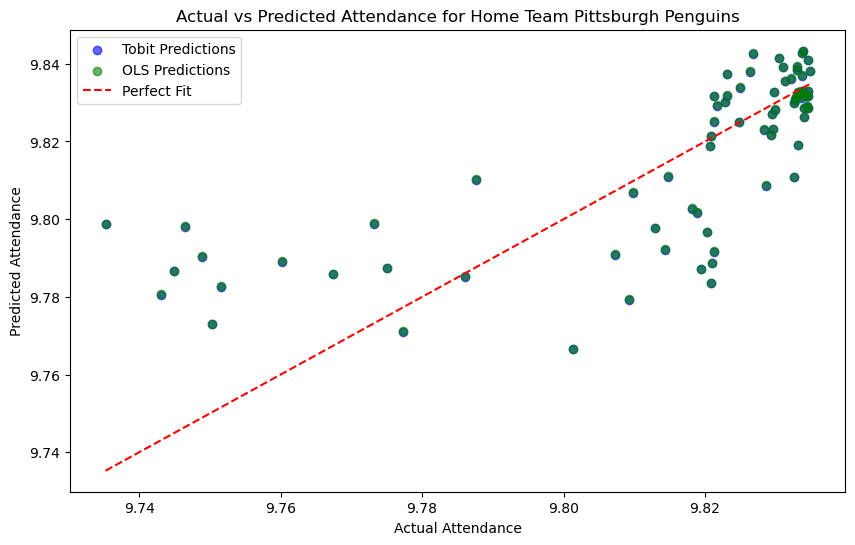


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Pittsburgh Penguins:
  - Tobit: 0.0003653001505637611
  - OLS: 0.0003656908622293595



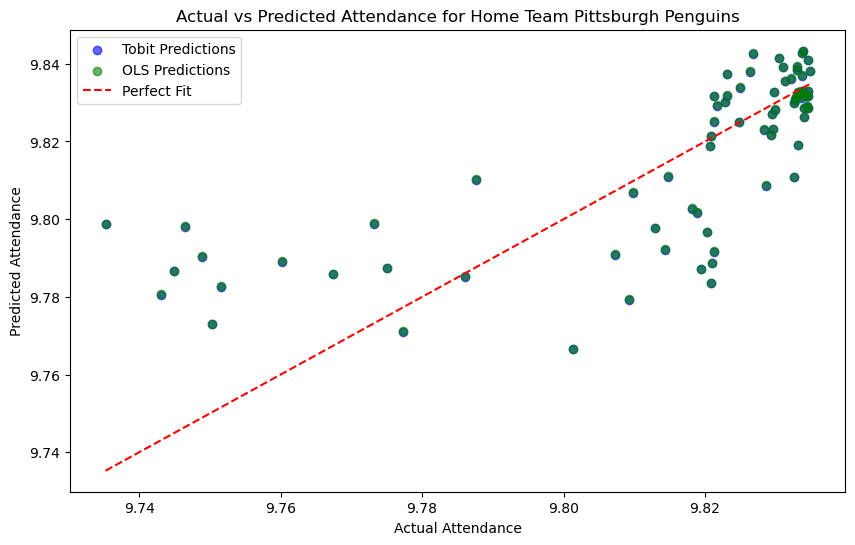


Running OLS_vs_Tobit for Pittsburgh Penguins with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



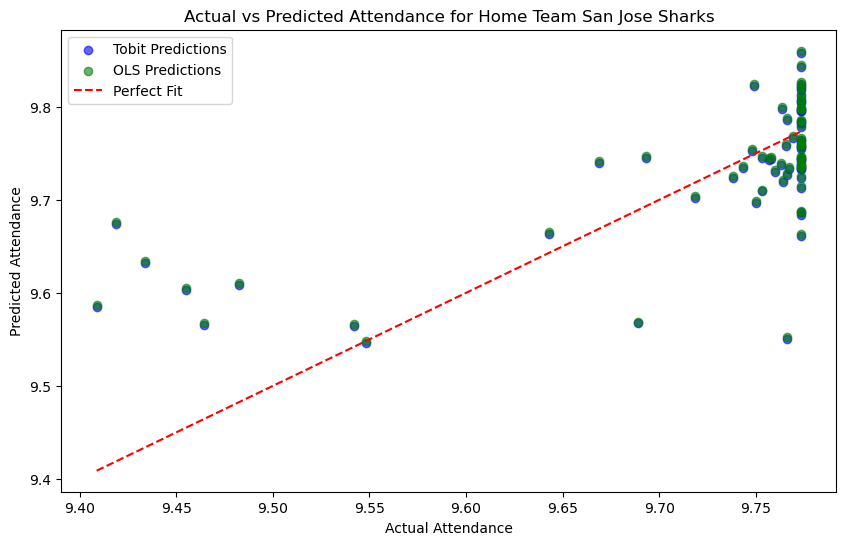


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



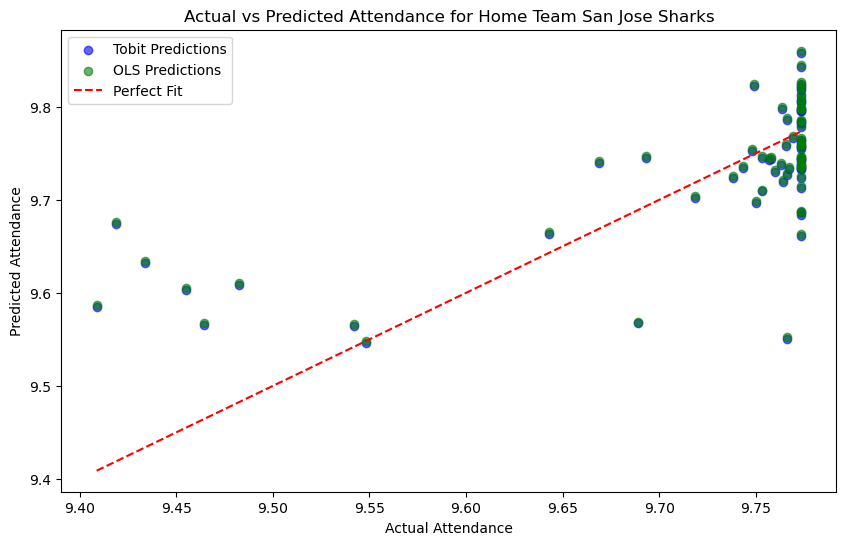


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



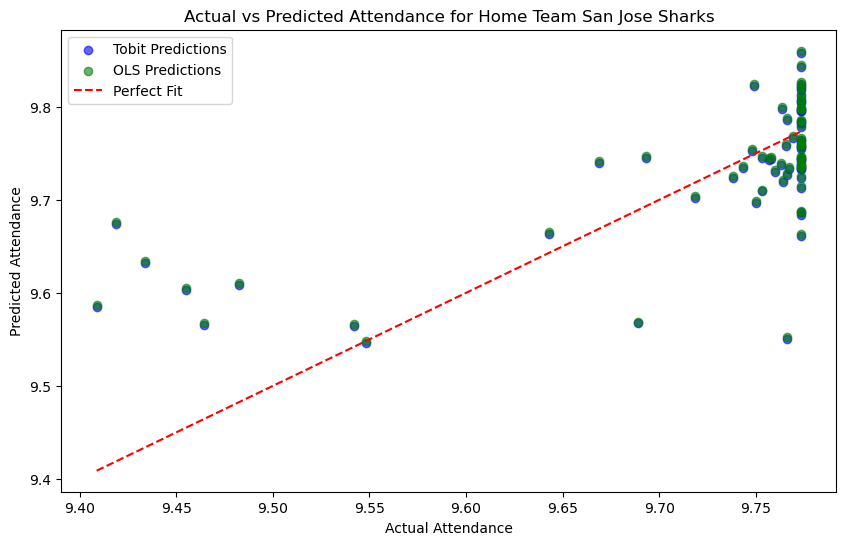


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



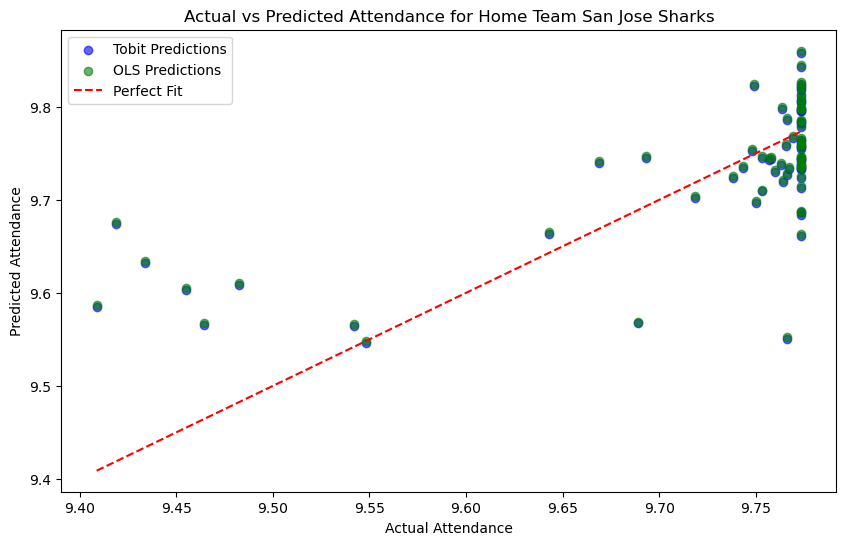


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



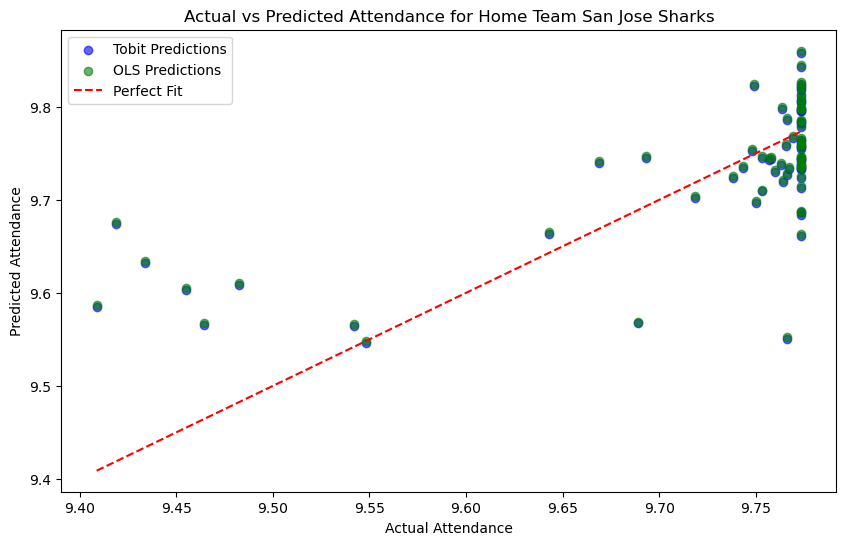


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team San Jose Sharks:
  - Tobit: 0.005409903043817847
  - OLS: 0.0054400259590377704



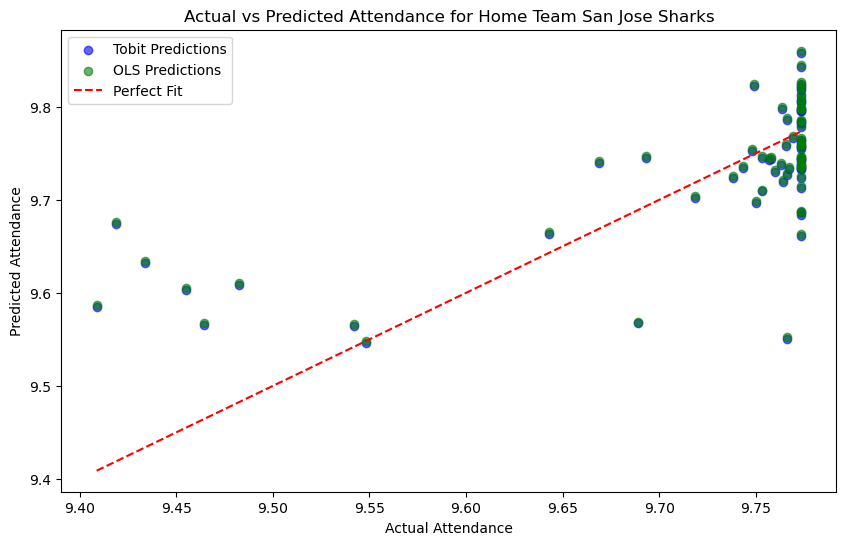


Running OLS_vs_Tobit for San Jose Sharks with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team St. Louis Blues:
  - Tobit: 0.003159875675958402
  - OLS: 0.003162795982027382



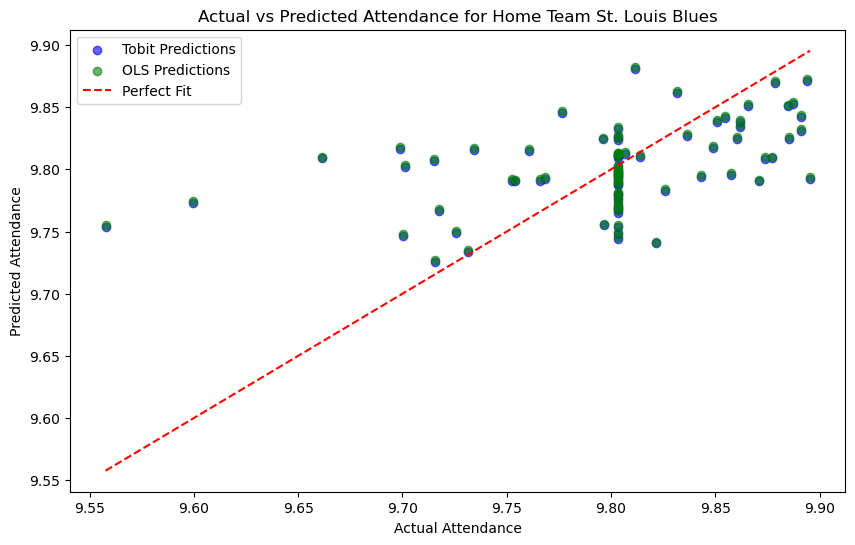


Running OLS_vs_Tobit for St. Louis Blues with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team St. Louis Blues:
  - Tobit: 0.003159875675958402
  - OLS: 0.003162795982027382



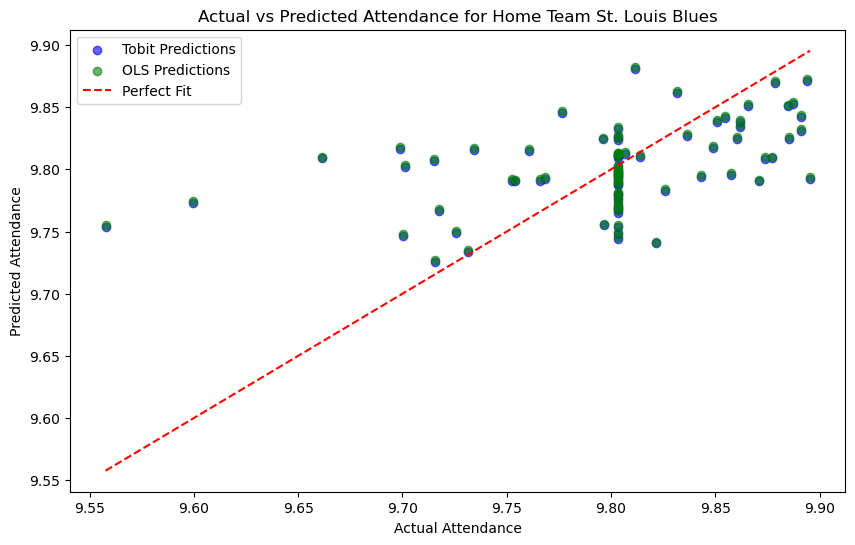


Running OLS_vs_Tobit for St. Louis Blues with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team St. Louis Blues:
  - Tobit: 0.003159875675958402
  - OLS: 0.003162795982027382



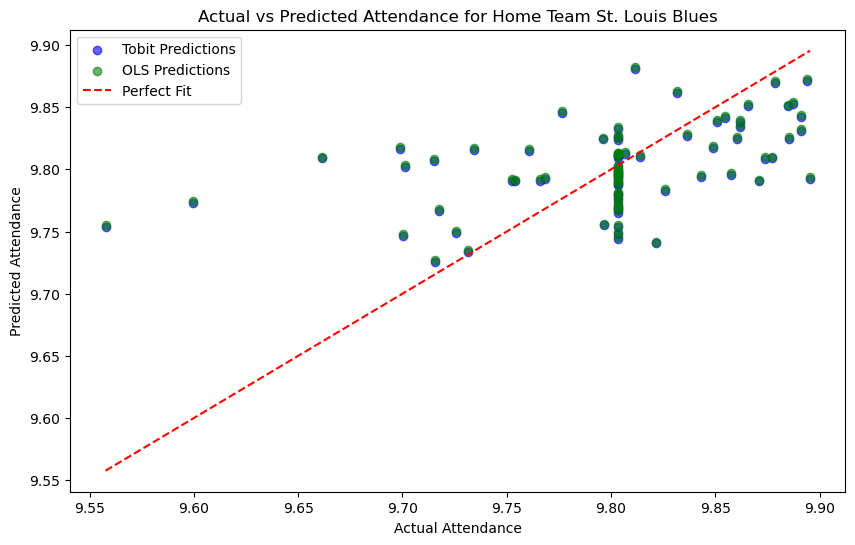


Running OLS_vs_Tobit for St. Louis Blues with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



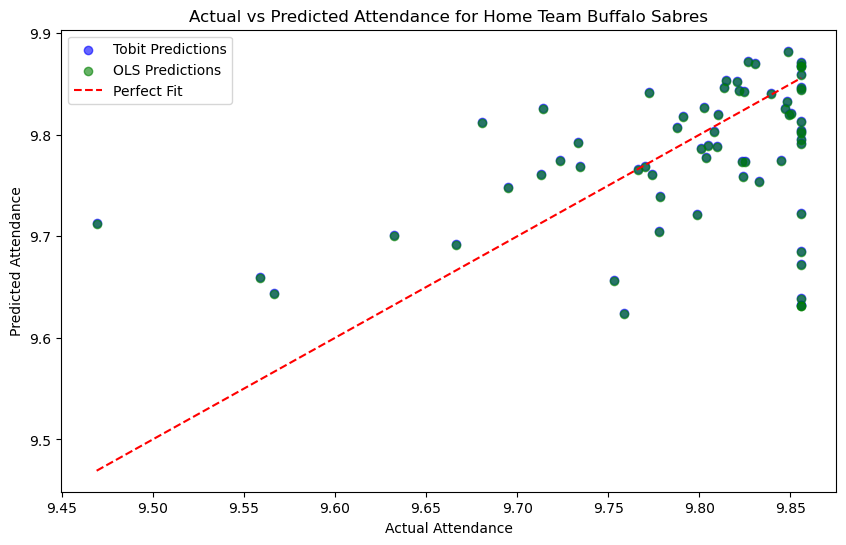


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



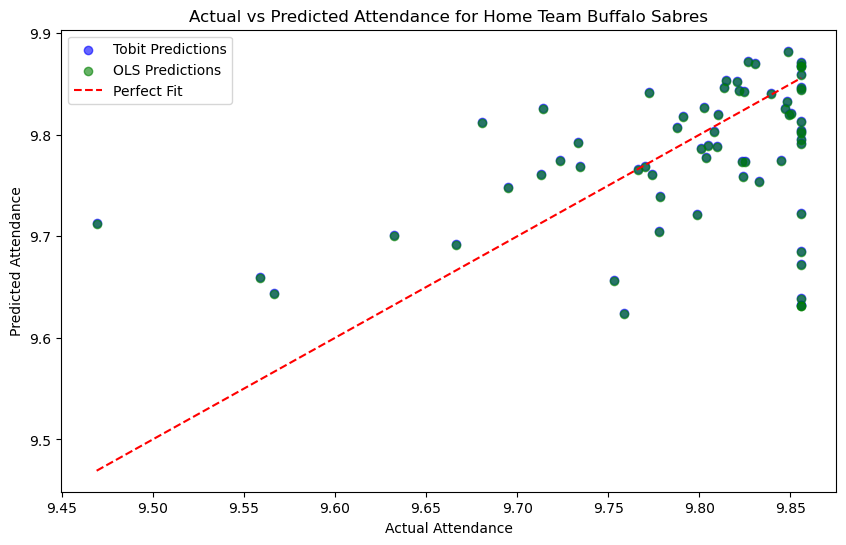


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



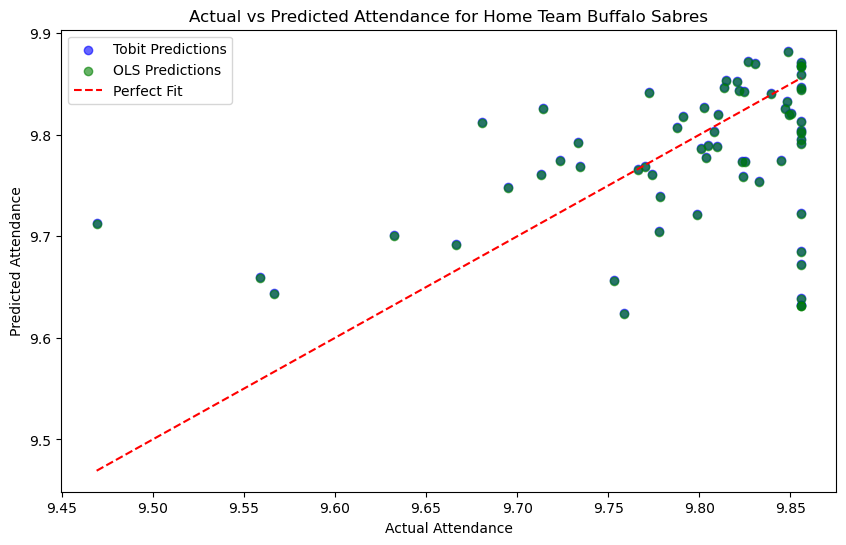


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



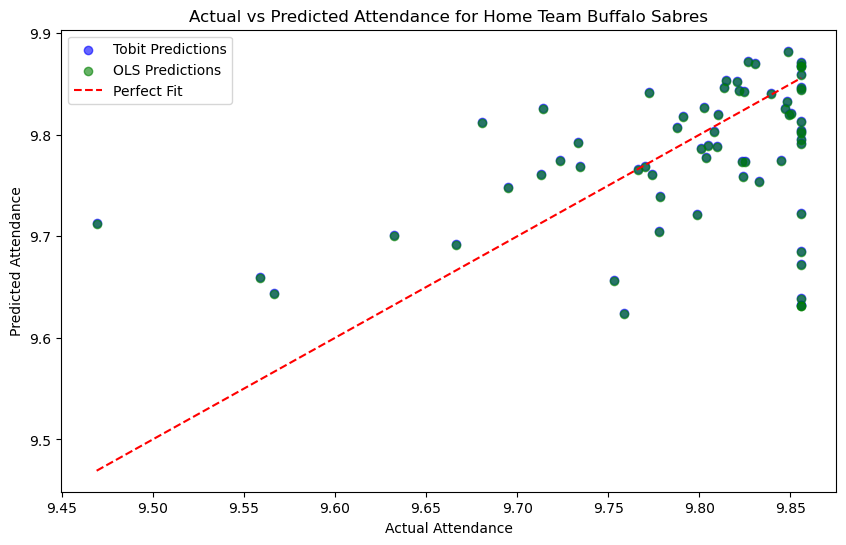


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



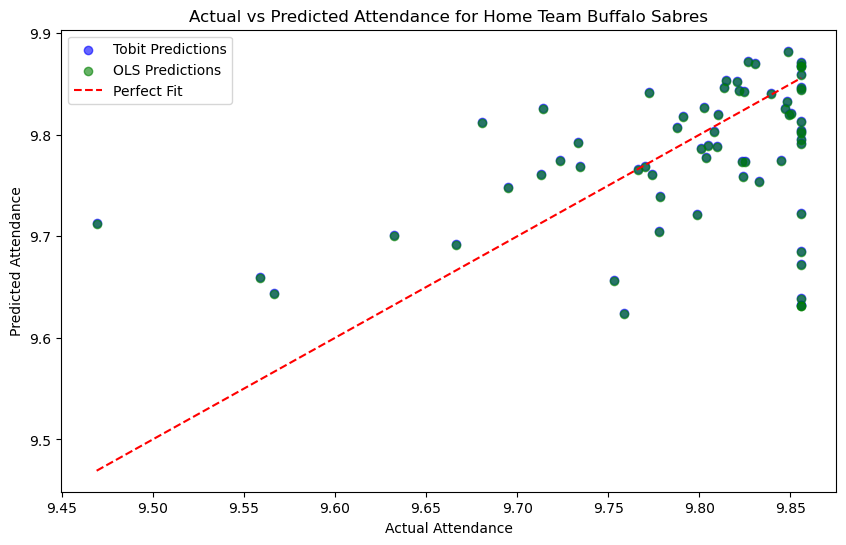


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Buffalo Sabres:
  - Tobit: 0.006868901122910981
  - OLS: 0.006897505843205422



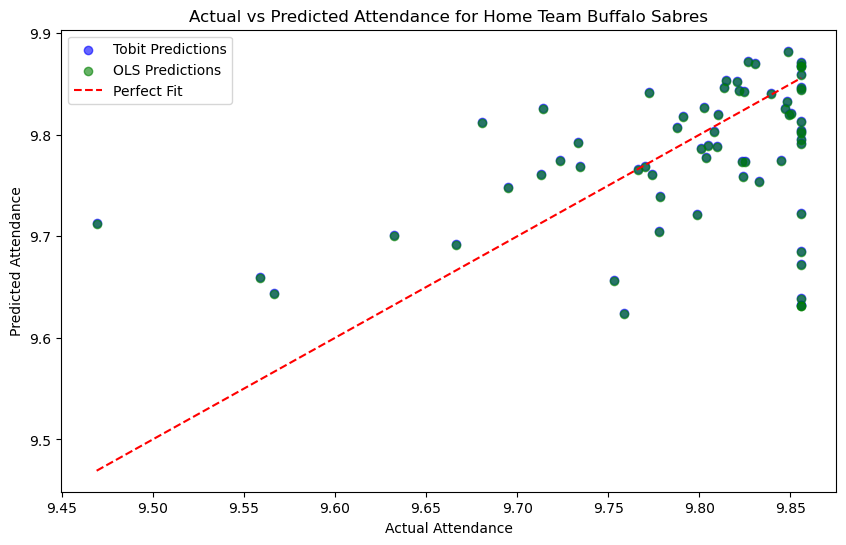


Running OLS_vs_Tobit for Buffalo Sabres with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



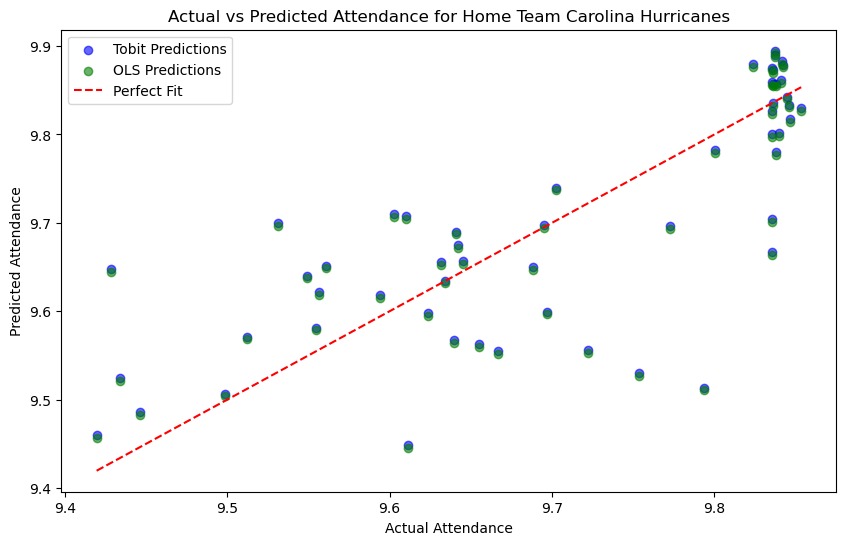


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



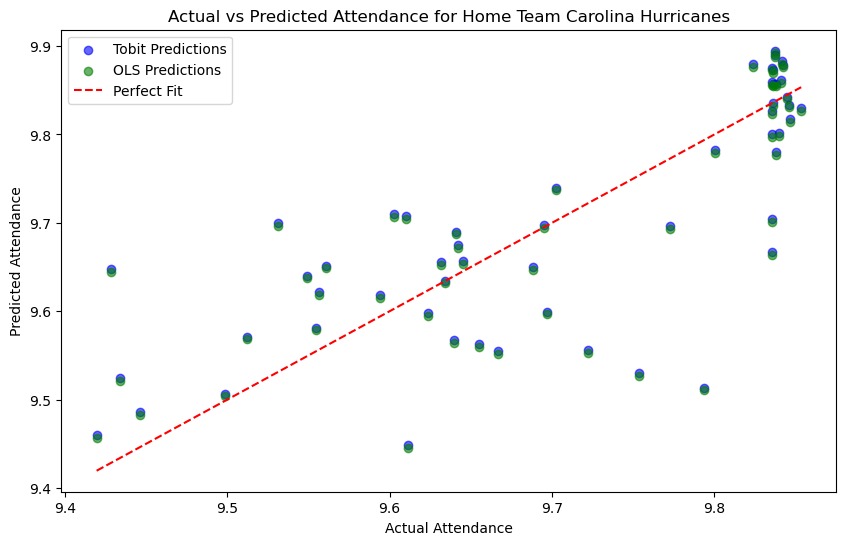


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



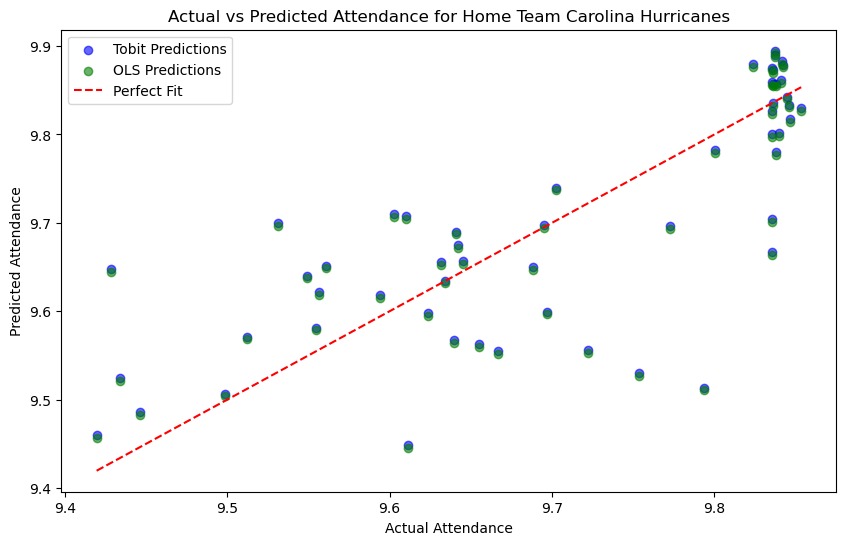


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



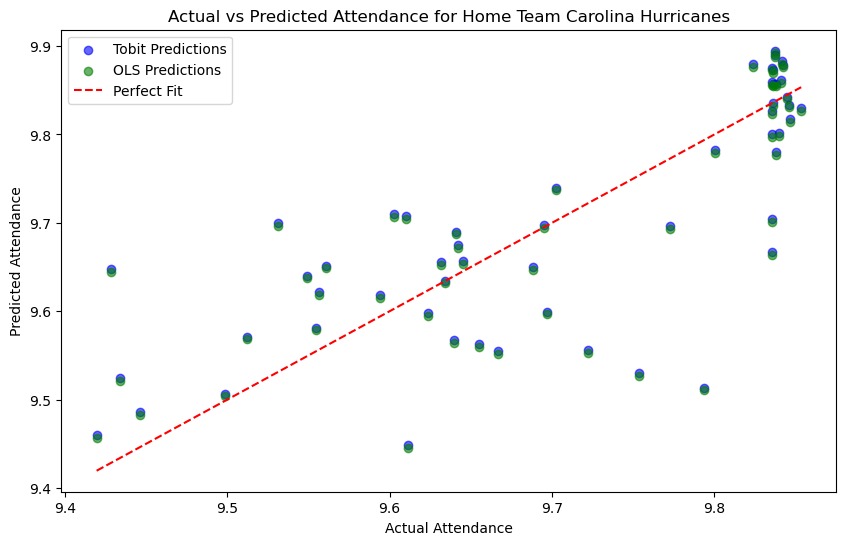


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



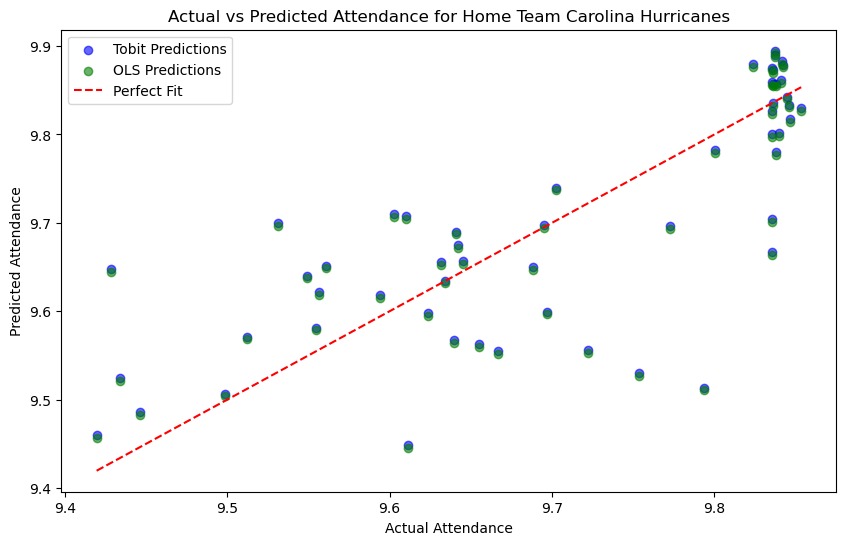


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Carolina Hurricanes:
  - Tobit: 0.00793127091581412
  - OLS: 0.007959430720026493



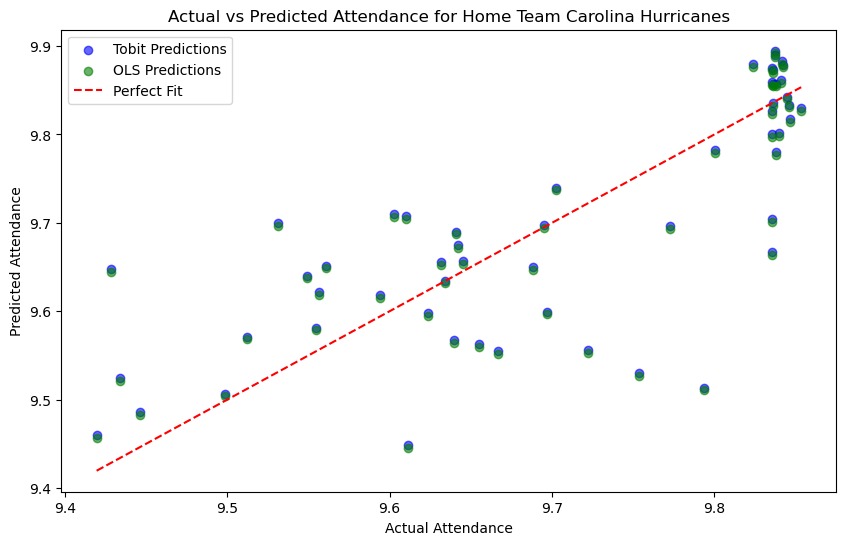


Running OLS_vs_Tobit for Carolina Hurricanes with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007611341010063063
  - OLS: 0.007630642632640622



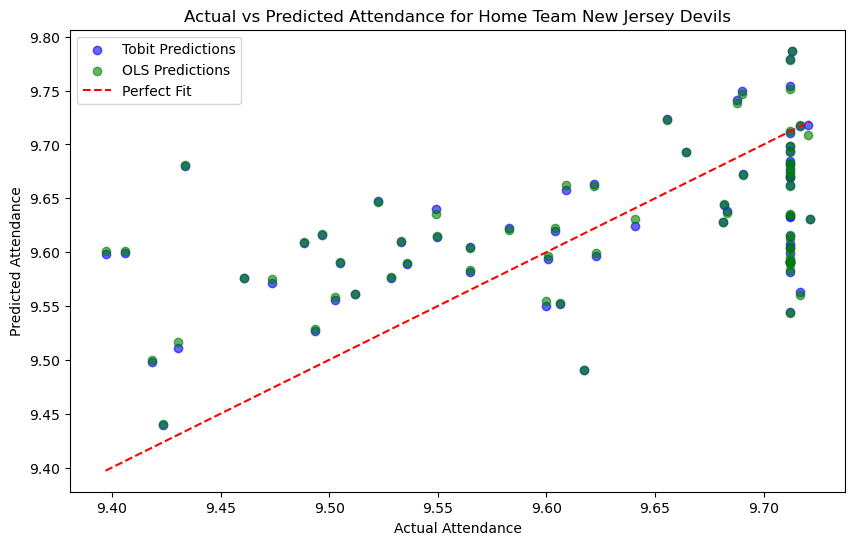


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007604993797430063
  - OLS: 0.007630642632640622



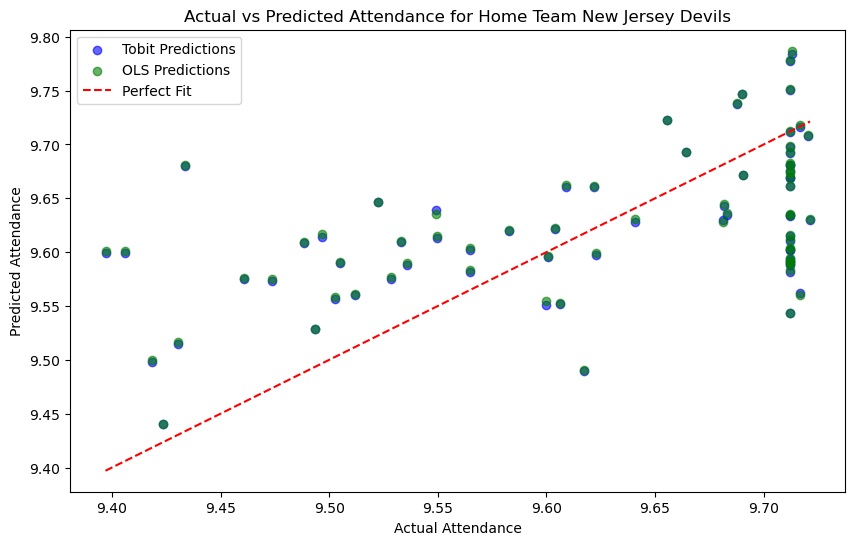


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007622749507794167
  - OLS: 0.007630642632640622



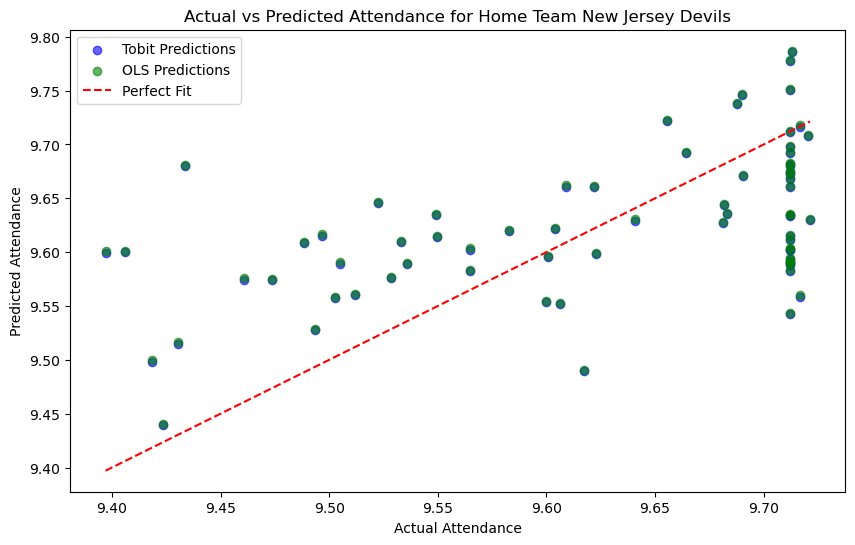


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007622749507794167
  - OLS: 0.007630642632640622



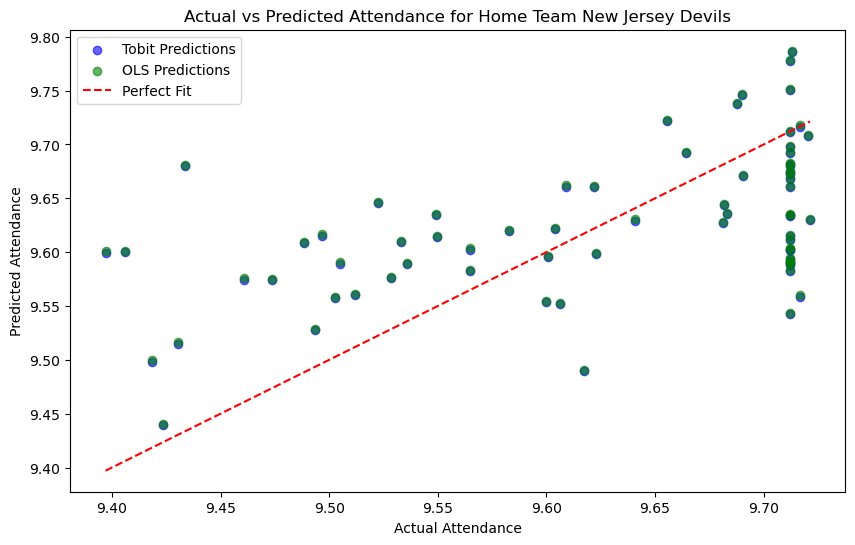


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007622749507794167
  - OLS: 0.007630642632640622



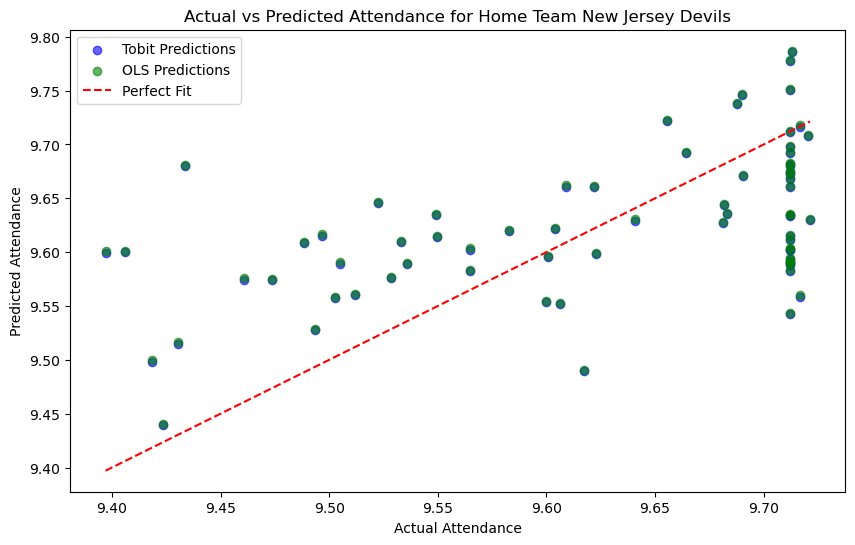


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team New Jersey Devils:
  - Tobit: 0.007622749507794167
  - OLS: 0.007630642632640622



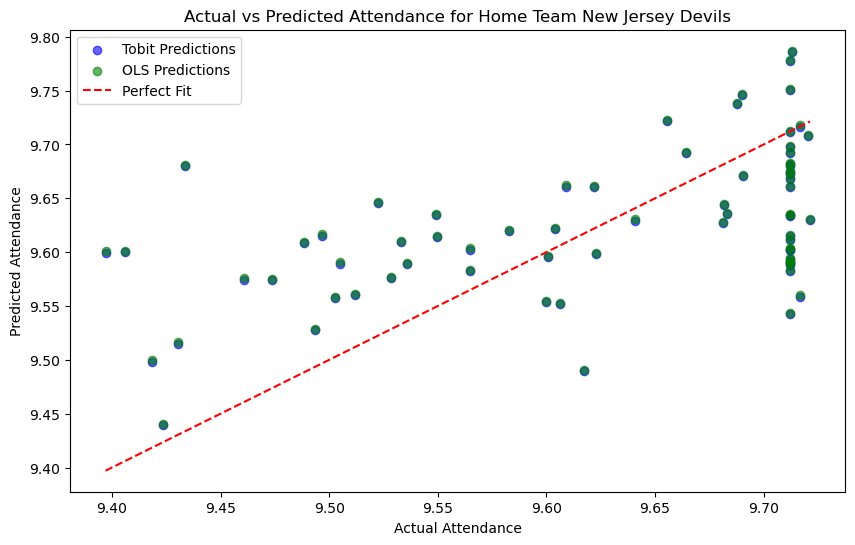


Running OLS_vs_Tobit for New Jersey Devils with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



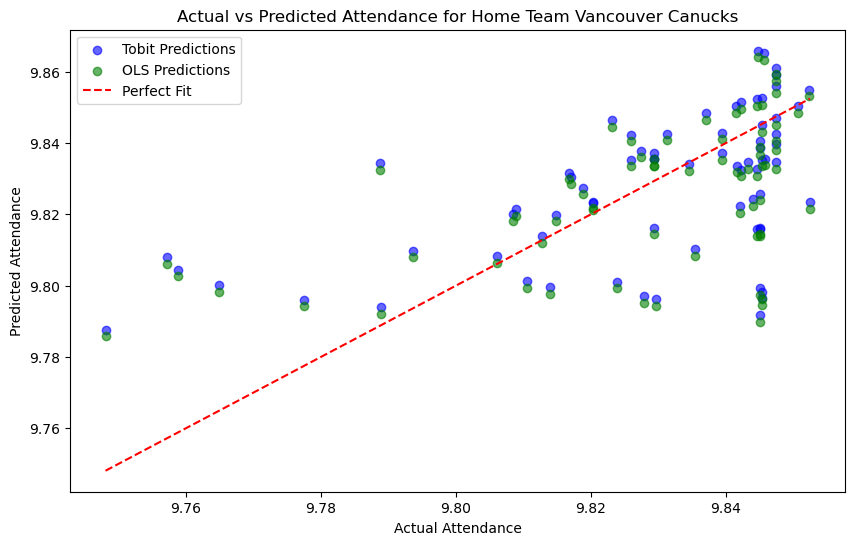


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



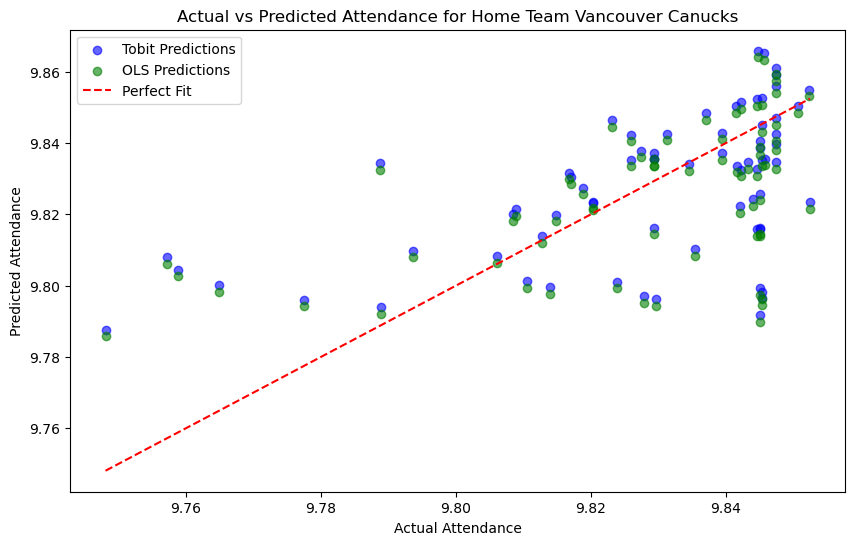


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



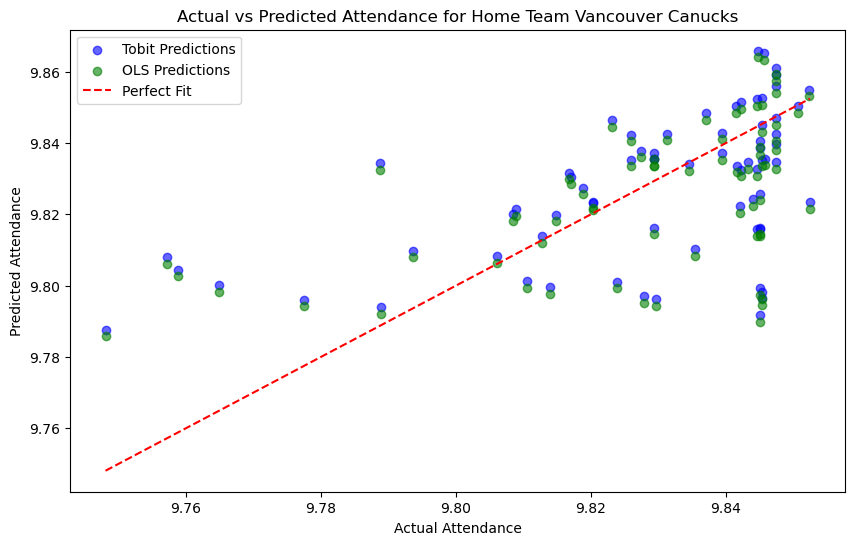


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



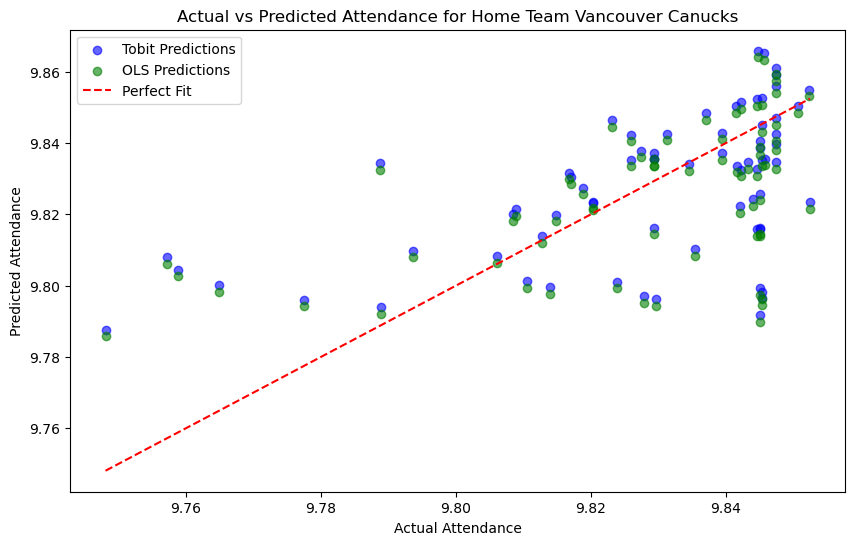


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



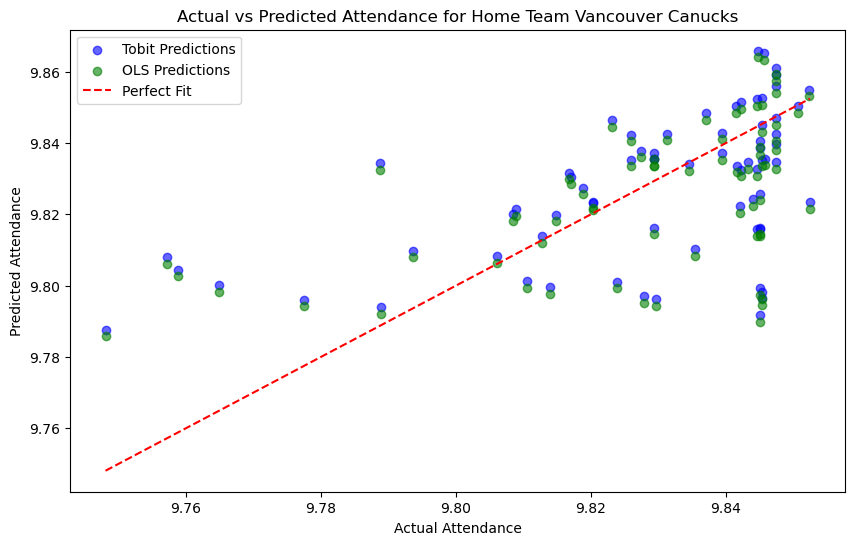


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Vancouver Canucks:
  - Tobit: 0.00045219885576344314
  - OLS: 0.0004591737427132185



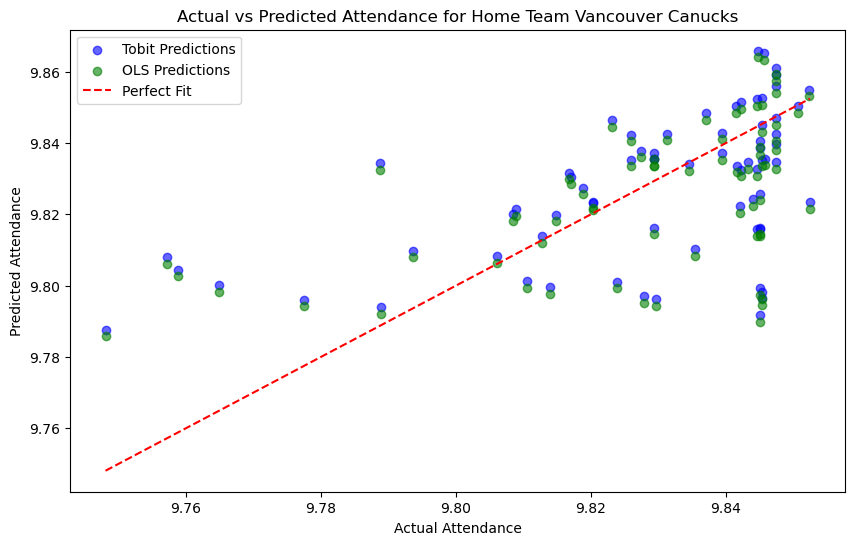


Running OLS_vs_Tobit for Vancouver Canucks with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Nashville Predators:
  - Tobit: 0.0005227438563135128
  - OLS: 0.0005241220489359288



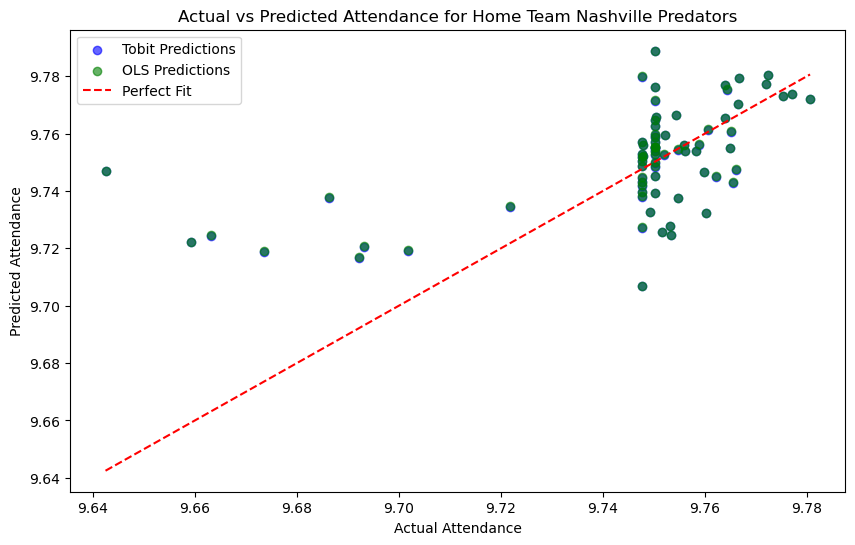


Running OLS_vs_Tobit for Nashville Predators with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Nashville Predators:
  - Tobit: 0.0005227438563135128
  - OLS: 0.0005241220489359288



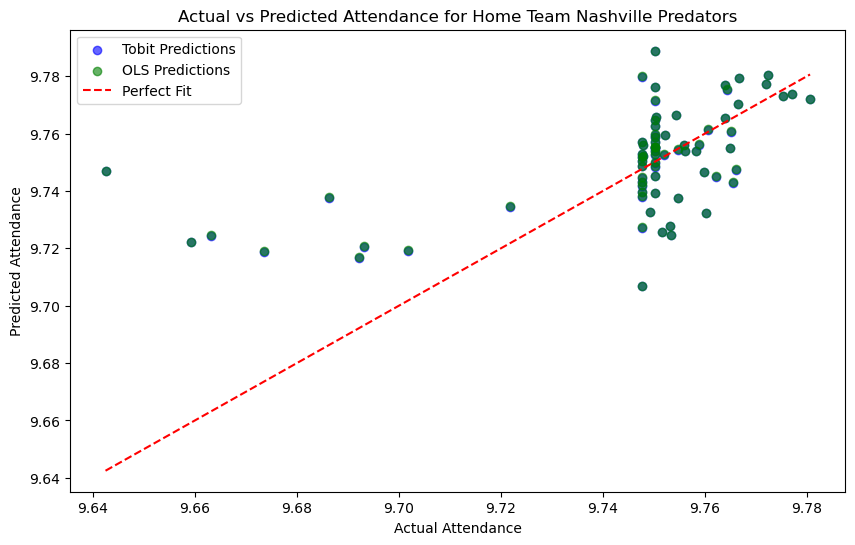


Running OLS_vs_Tobit for Nashville Predators with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Nashville Predators:
  - Tobit: 0.0005227438563135128
  - OLS: 0.0005241220489359288



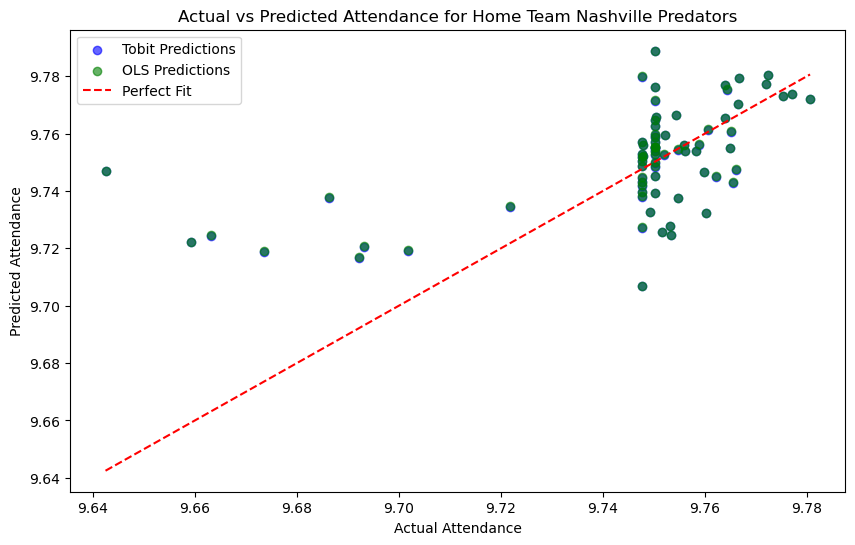


Running OLS_vs_Tobit for Nashville Predators with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Nashville Predators:
  - Tobit: 0.0005227438563135128
  - OLS: 0.0005241220489359288



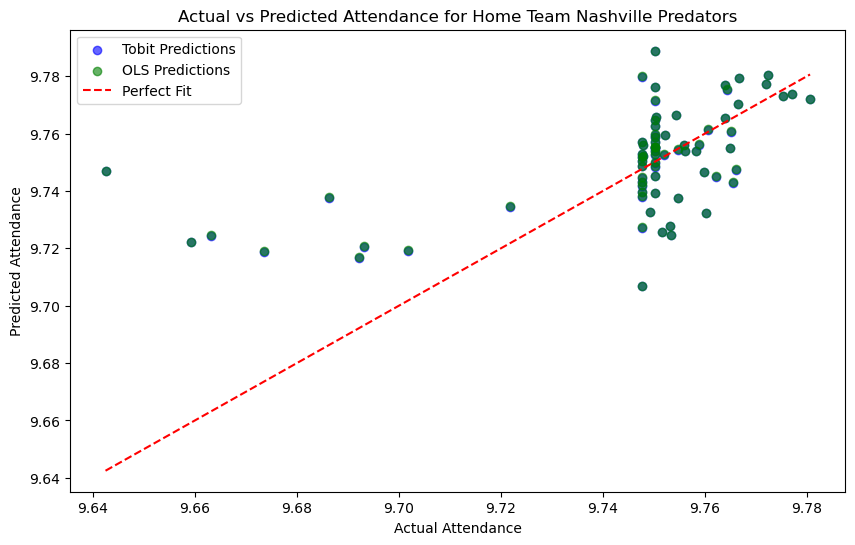


Running OLS_vs_Tobit for Nashville Predators with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Nashville Predators:
  - Tobit: 0.0005227438563135128
  - OLS: 0.0005241220489359288



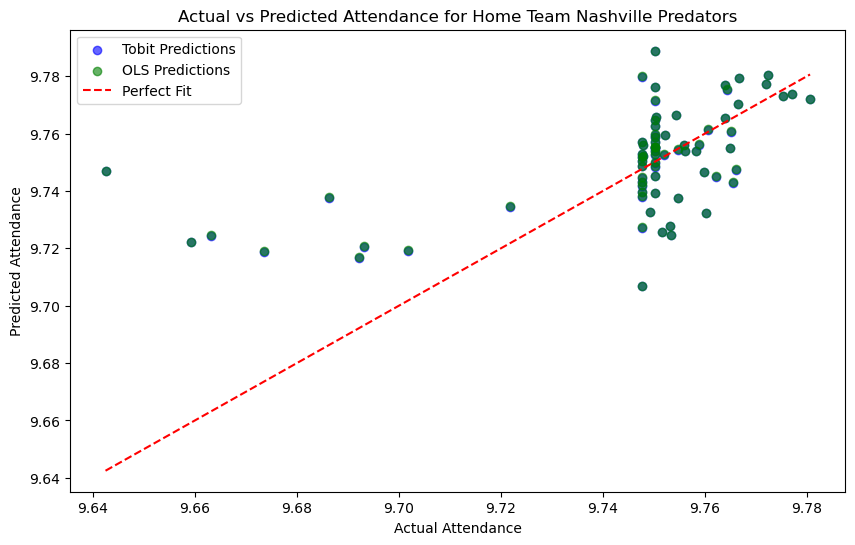


Running OLS_vs_Tobit for Nashville Predators with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



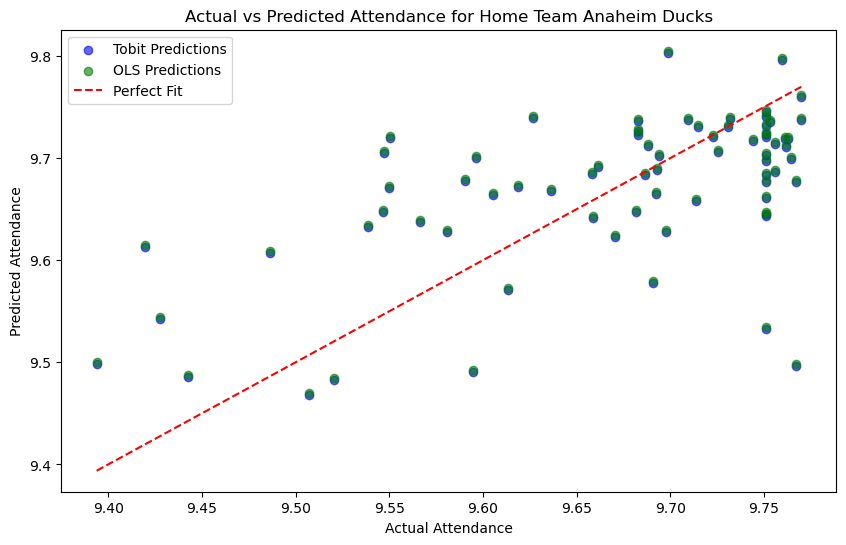


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



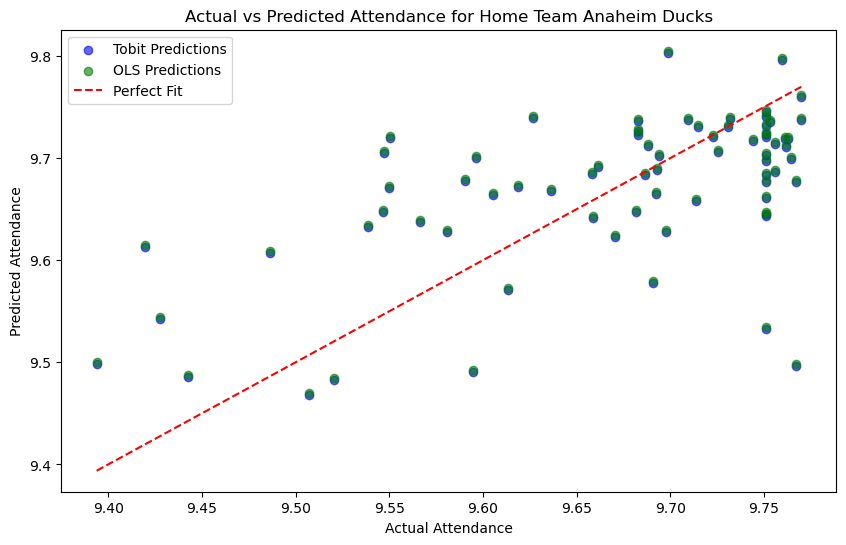


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



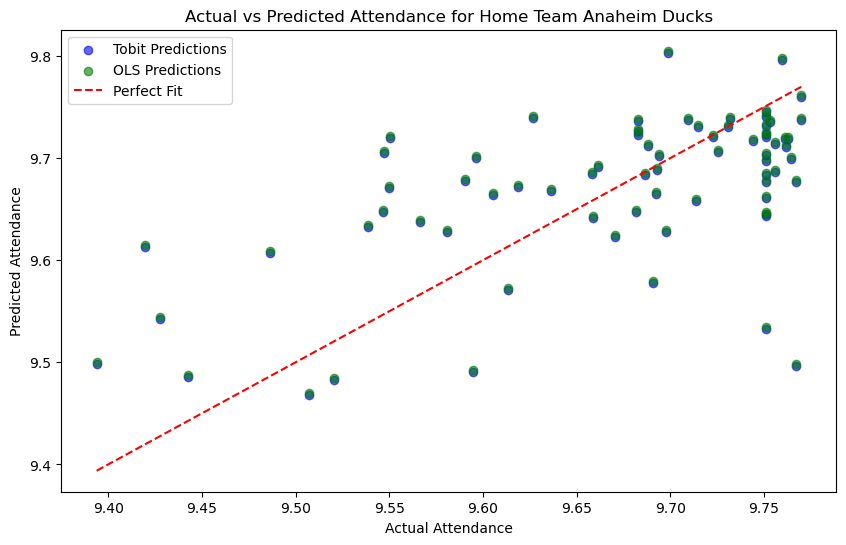


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



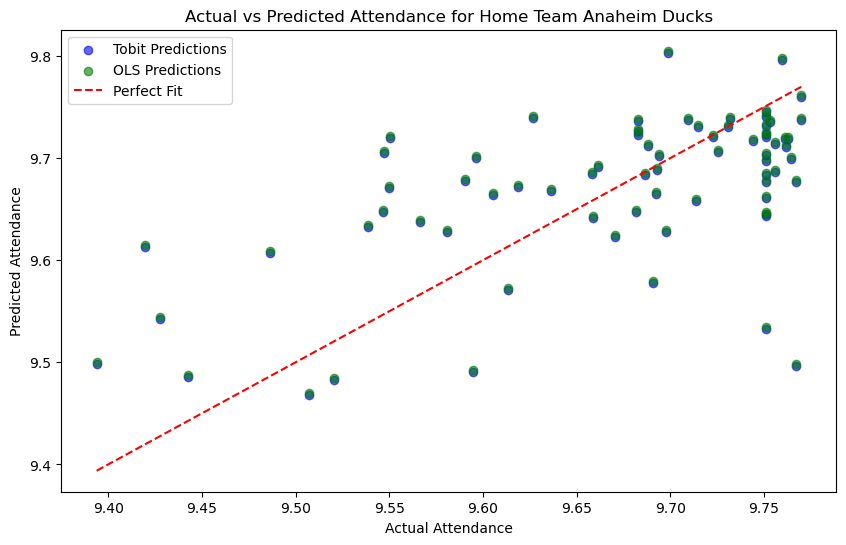


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



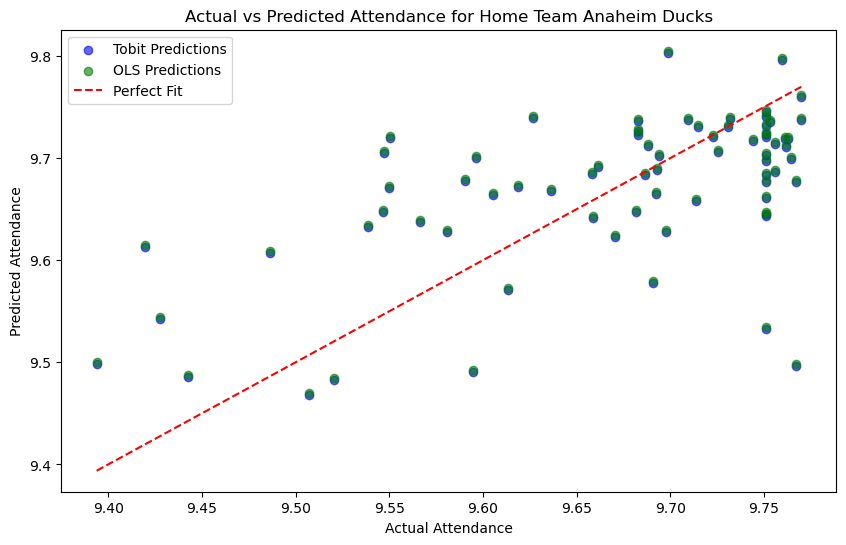


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Anaheim Ducks:
  - Tobit: 0.006629417380363125
  - OLS: 0.00663090948215078



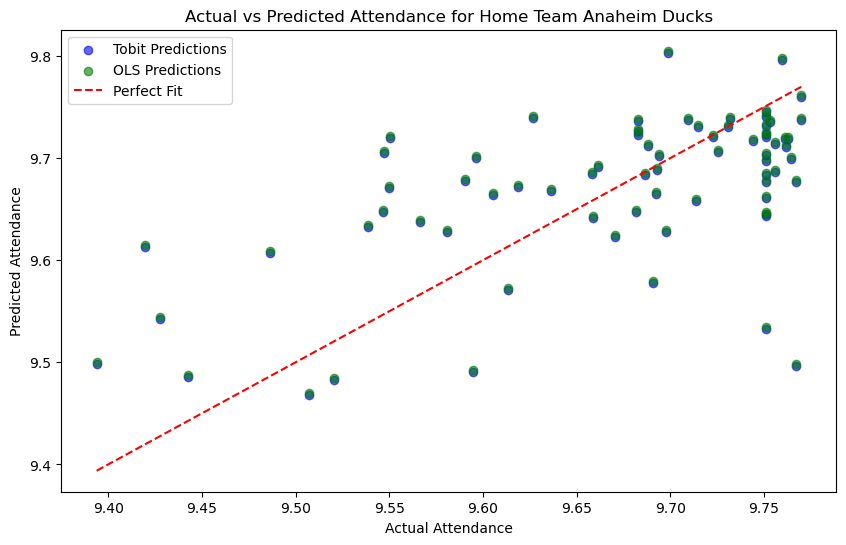


Running OLS_vs_Tobit for Anaheim Ducks with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



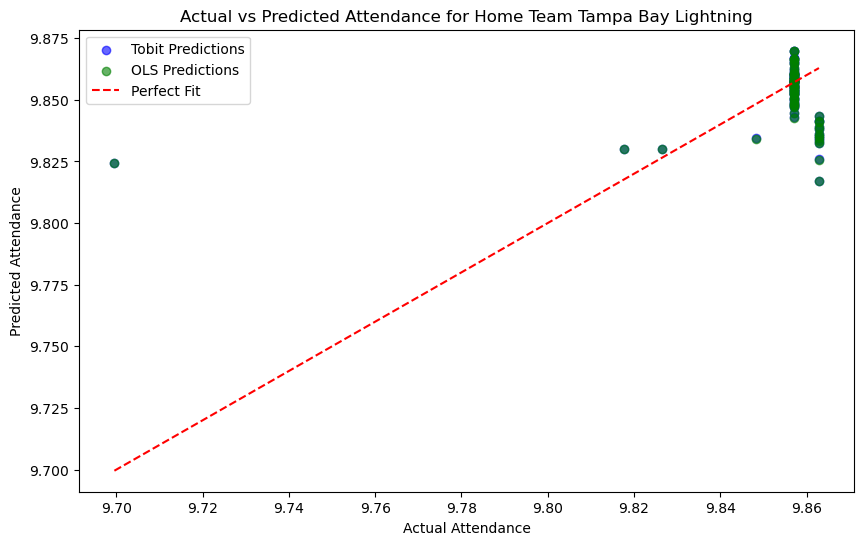


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



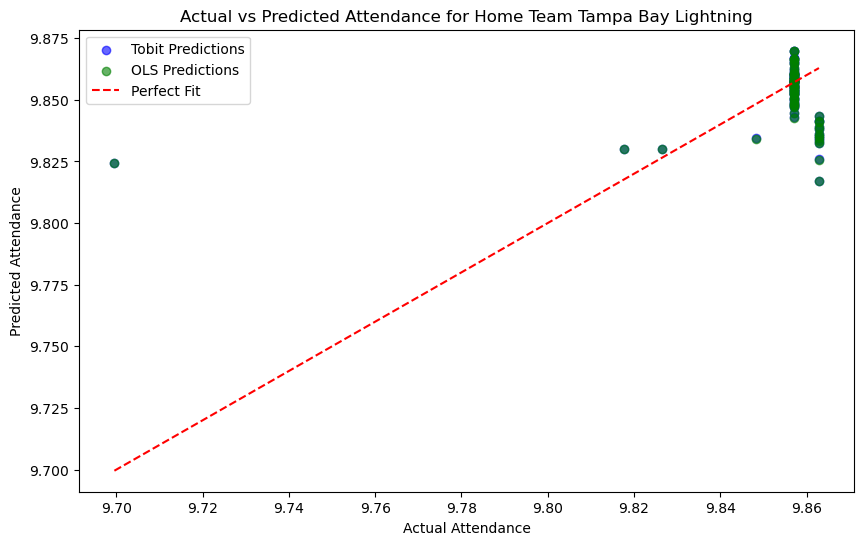


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



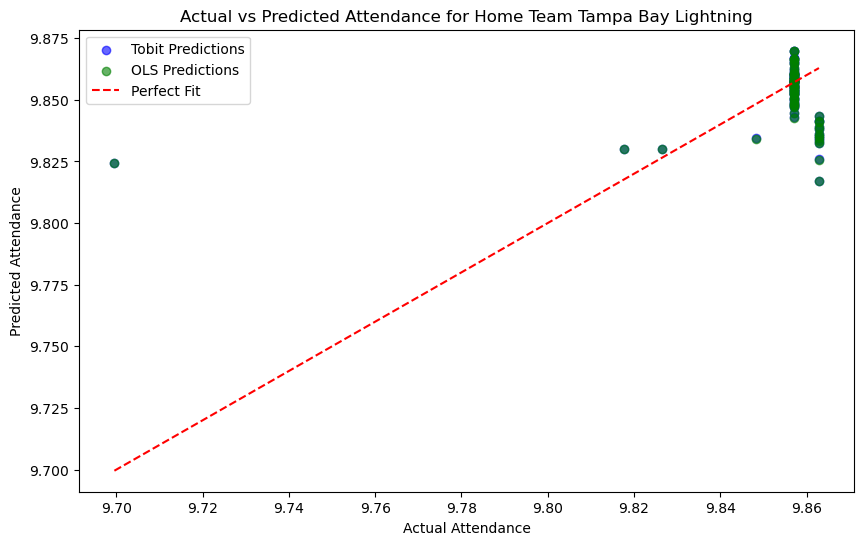


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



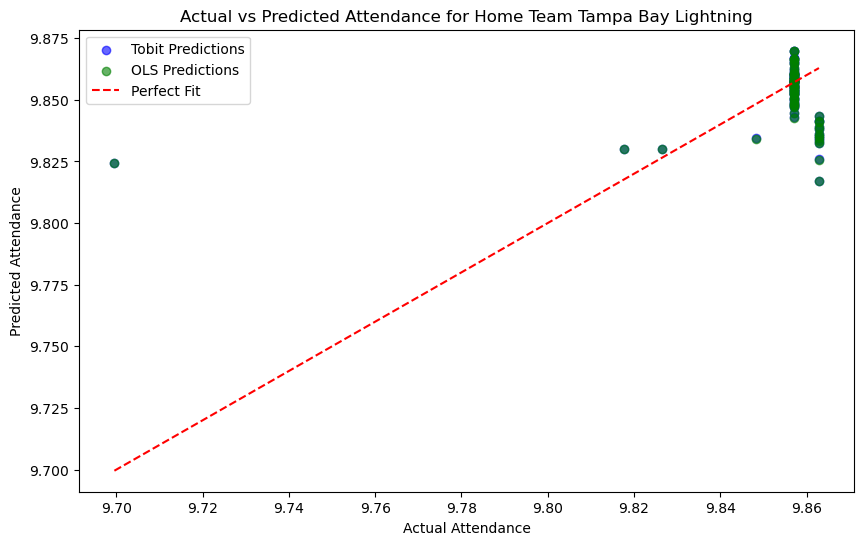


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



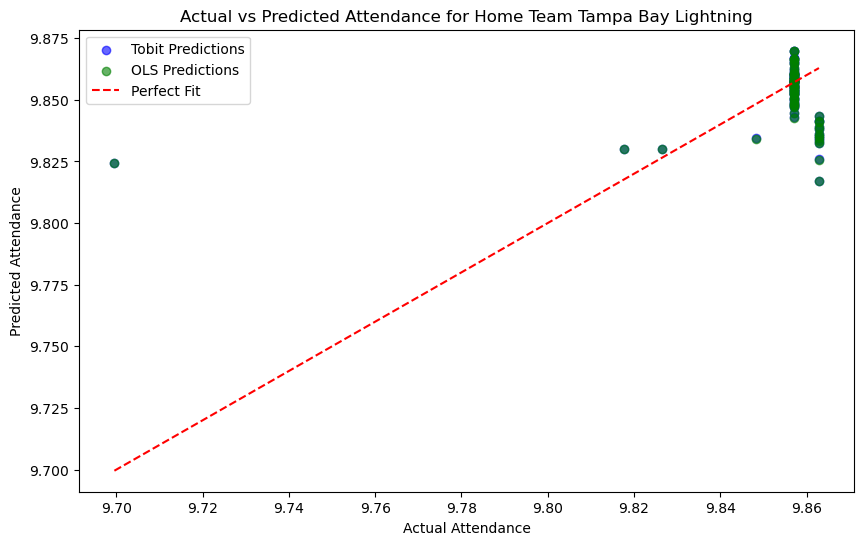


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Tampa Bay Lightning:
  - Tobit: 0.0003790694000489625
  - OLS: 0.00037981862808075204



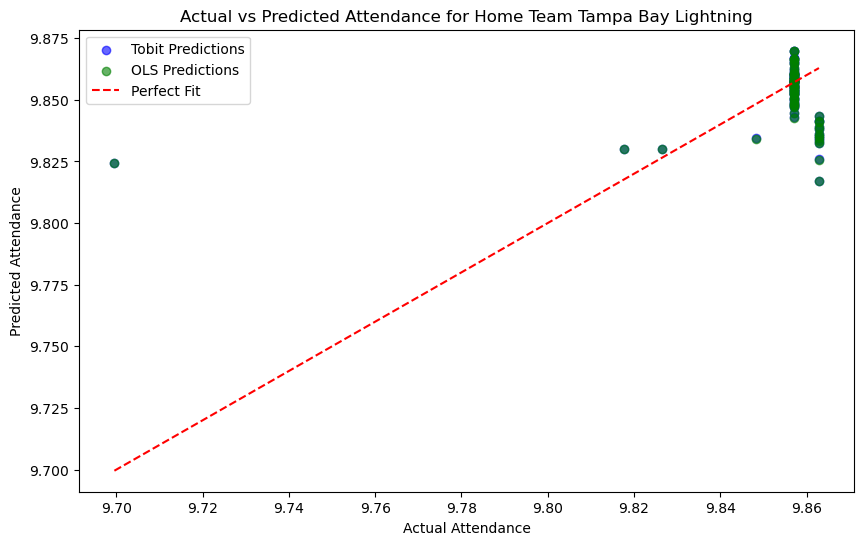


Running OLS_vs_Tobit for Tampa Bay Lightning with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Florida Panthers:
  - Tobit: 0.016935514983572562
  - OLS: 0.01693762109912213



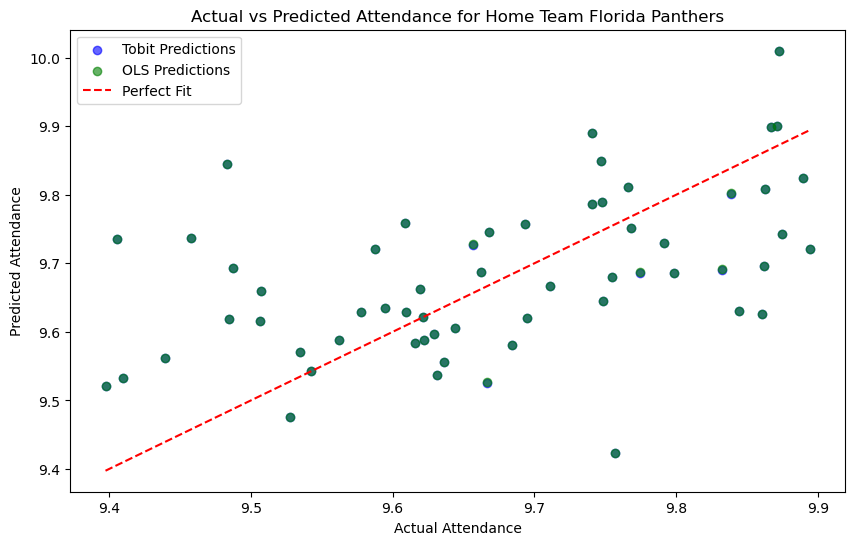


Running OLS_vs_Tobit for Florida Panthers with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Florida Panthers:
  - Tobit: 0.016935514983572562
  - OLS: 0.01693762109912213



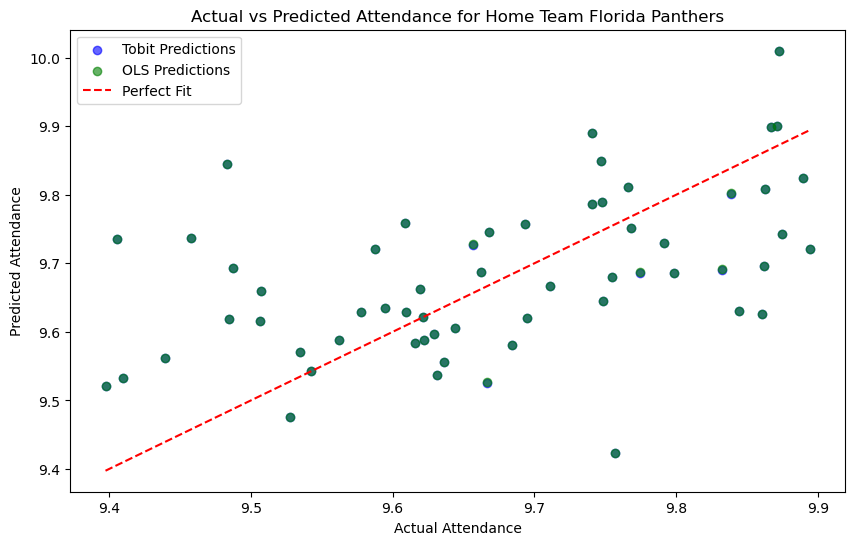


Running OLS_vs_Tobit for Florida Panthers with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Florida Panthers:
  - Tobit: 0.016935514983572562
  - OLS: 0.01693762109912213



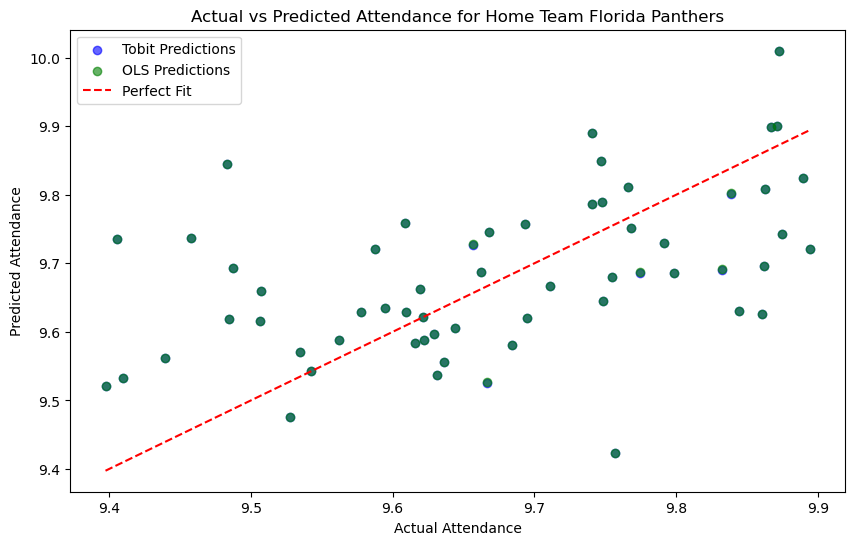


Running OLS_vs_Tobit for Florida Panthers with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Florida Panthers:
  - Tobit: 0.016935514983572562
  - OLS: 0.01693762109912213



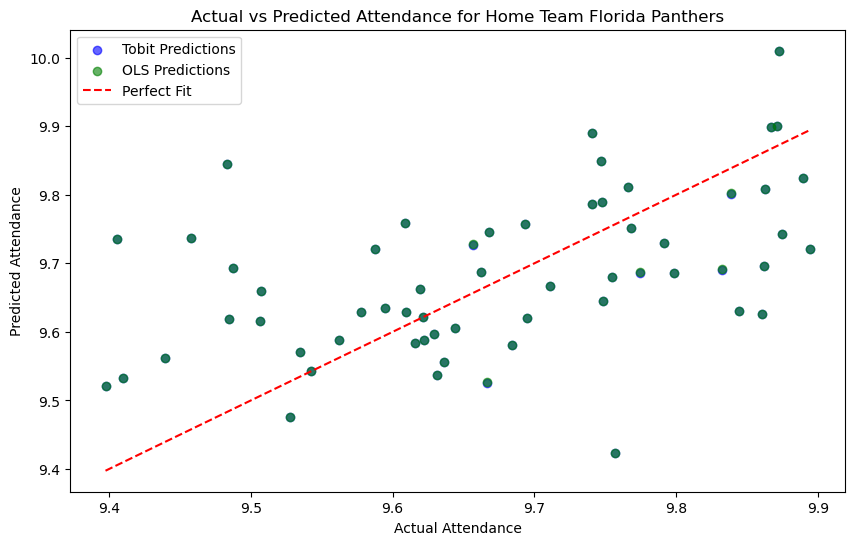


Running OLS_vs_Tobit for Florida Panthers with multiplier = 1.2
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



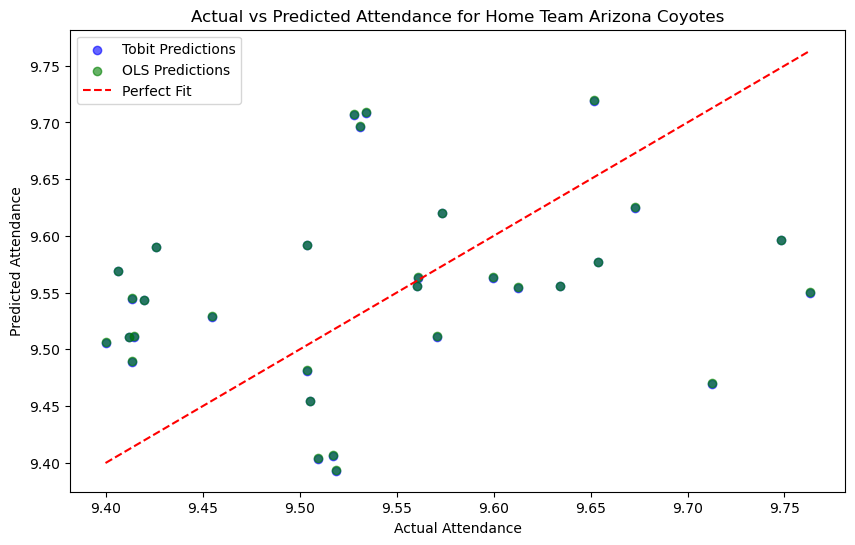


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.0333333333333332
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



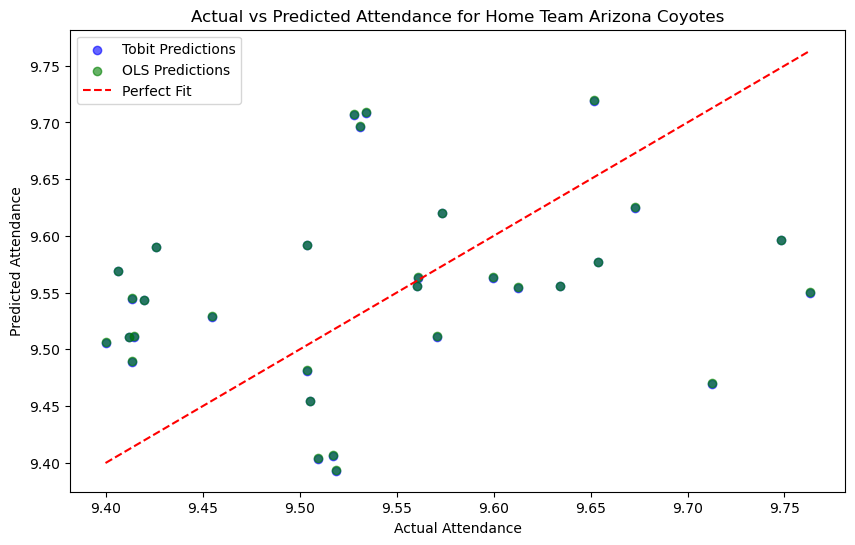


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.0666666666666667
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



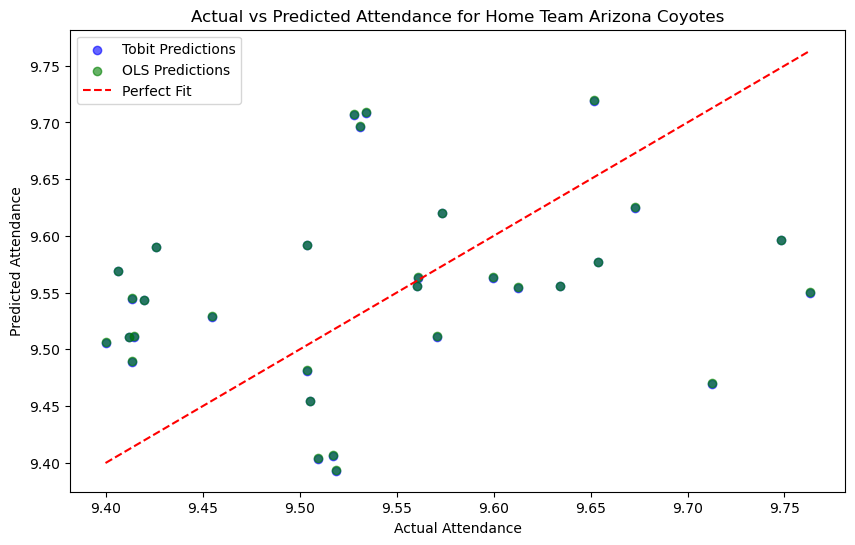


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.1
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



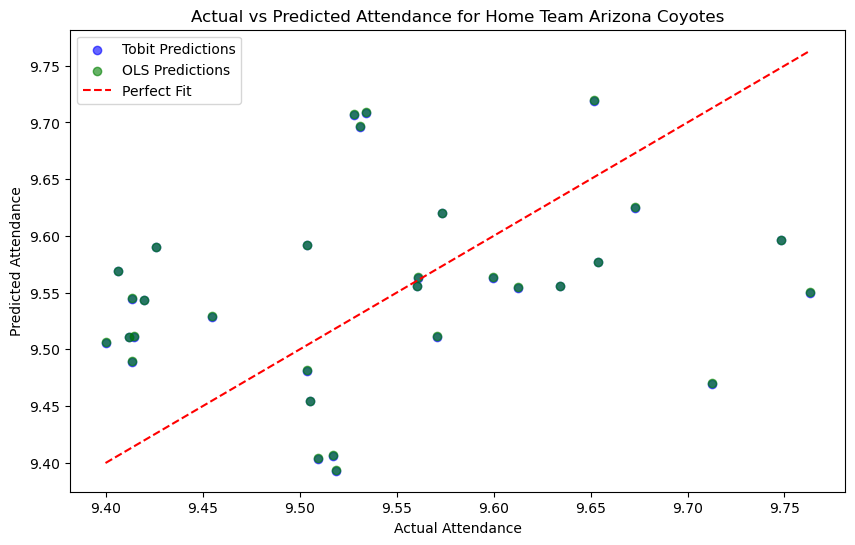


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.1333333333333333
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



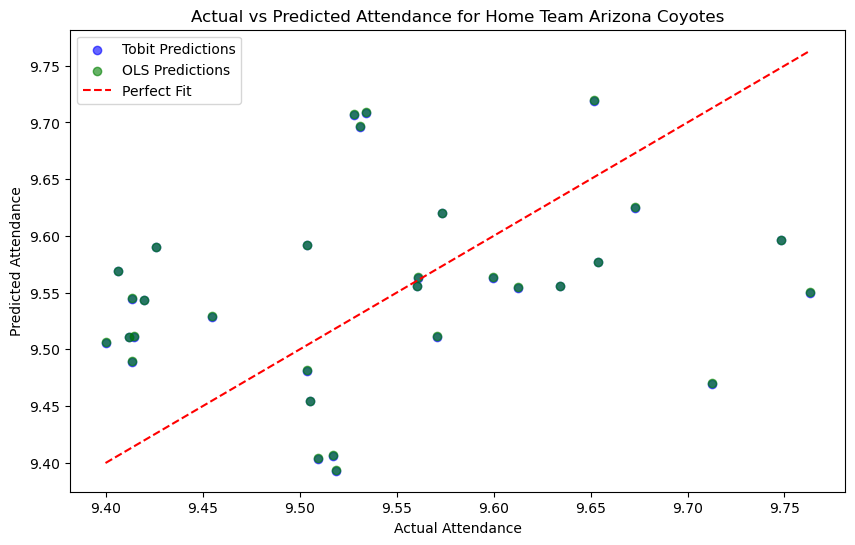


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.1666666666666665
dependent variable LA

Mean Squared Error (MSE) for Home Team Arizona Coyotes:
  - Tobit: 0.013688382946191676
  - OLS: 0.013705616636009377



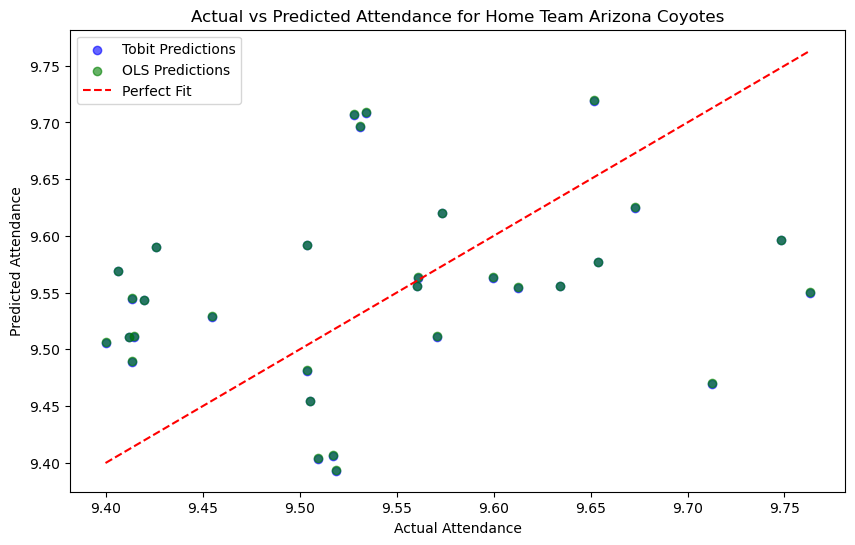


Running OLS_vs_Tobit for Arizona Coyotes with multiplier = 1.2


In [64]:
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

home_teams = df_att['H'].unique()  # Get unique home teams
multipliers = np.linspace(0.90, 1.20, 10)  # Define multiplier range

for team in home_teams:
    df_team = df_att[df_att['H'] == team]  # Filter for each team
    
    for multiplier in multipliers:
        upper_threshold = df_team['CAP'].iloc[0] * multiplier  # Compute threshold
        val = OLS_vs_Tobit(df_team, upper_threshold)  # Call function

        if val == 1:
            print(f'\nRunning OLS_vs_Tobit for {team} with multiplier = {multiplier}')